In [3]:
import pandas as pd


# 1. orders_cleaned.csv

In [4]:
orders = pd.read_csv('../cleaned_data/orders_cleaned.csv')

In [5]:
print(orders.shape)
print(orders.columns.tolist())

(14427, 26)
['order_id', 'customer_id', 'product_id', 'quantity', 'order_date', 'origin_hub', 'origin_city', 'destination_city', 'destination_state', 'destination_pincode', 'destination_lat', 'destination_lon', 'distance_km', 'package_weight', 'is_fragile', 'is_hazmat', 'cold_chain_required', 'delivery_priority', 'payment_mode', 'order_value_inr', 'weather_condition_at_dest', 'promised_eta_hours', 'actual_delivery_hours', 'delivery_cost_inr', 'transport_mode', 'order_status']


Dataset information

In [6]:
print(orders.info())

<class 'pandas.DataFrame'>
RangeIndex: 14427 entries, 0 to 14426
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   order_id                   14427 non-null  str    
 1   customer_id                14427 non-null  str    
 2   product_id                 14427 non-null  str    
 3   quantity                   14427 non-null  int64  
 4   order_date                 14427 non-null  str    
 5   origin_hub                 14427 non-null  str    
 6   origin_city                14427 non-null  str    
 7   destination_city           14427 non-null  str    
 8   destination_state          14427 non-null  str    
 9   destination_pincode        14427 non-null  int64  
 10  destination_lat            14427 non-null  float64
 11  destination_lon            14427 non-null  float64
 12  distance_km                14427 non-null  float64
 13  package_weight             14427 non-null  float64
 14  i

Check missing values

In [7]:
print(orders.isna().sum())

order_id                     0
customer_id                  0
product_id                   0
quantity                     0
order_date                   0
origin_hub                   0
origin_city                  0
destination_city             0
destination_state            0
destination_pincode          0
destination_lat              0
destination_lon              0
distance_km                  0
package_weight               0
is_fragile                   0
is_hazmat                    0
cold_chain_required          0
delivery_priority            0
payment_mode                 0
order_value_inr              0
weather_condition_at_dest    0
promised_eta_hours           0
actual_delivery_hours        0
delivery_cost_inr            0
transport_mode               0
order_status                 0
dtype: int64


Check duplicate rows

In [8]:
print("Duplicate rows:", orders.duplicated().sum())

Duplicate rows: 0


Separate numerical and categorical columns

In [9]:
numeric_cols = orders.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_cols = orders.select_dtypes(
    include=['object', 'str', 'string']
).columns.tolist()

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['quantity', 'destination_pincode', 'destination_lat', 'destination_lon', 'distance_km', 'package_weight', 'is_hazmat', 'order_value_inr', 'promised_eta_hours', 'actual_delivery_hours', 'delivery_cost_inr']

Categorical columns:
['order_id', 'customer_id', 'product_id', 'order_date', 'origin_hub', 'origin_city', 'destination_city', 'destination_state', 'is_fragile', 'delivery_priority', 'payment_mode', 'weather_condition_at_dest', 'transport_mode', 'order_status']


Define analysis columns

In [10]:
numeric_eda_cols = [
    'quantity',
    'distance_km',
    'package_weight',
    'order_value_inr',
    'promised_eta_hours',
    'actual_delivery_hours',
    'delivery_cost_inr'
]

categorical_eda_cols = [
    'origin_hub',
    'origin_city',
    'destination_city',
    'destination_state',
    'is_fragile',
    'is_hazmat',
    'cold_chain_required',
    'delivery_priority',
    'payment_mode',
    'weather_condition_at_dest',
    'transport_mode',
    'order_status'
]

print("Numerical EDA columns:")
print(numeric_eda_cols)

print("\nCategorical EDA columns:")
print(categorical_eda_cols)

Numerical EDA columns:
['quantity', 'distance_km', 'package_weight', 'order_value_inr', 'promised_eta_hours', 'actual_delivery_hours', 'delivery_cost_inr']

Categorical EDA columns:
['origin_hub', 'origin_city', 'destination_city', 'destination_state', 'is_fragile', 'is_hazmat', 'cold_chain_required', 'delivery_priority', 'payment_mode', 'weather_condition_at_dest', 'transport_mode', 'order_status']


In [11]:
numerical_eda_cols = [
    'quantity',
    'distance_km',
    'package_weight',
    'order_value_inr',
    'promised_eta_hours',
    'actual_delivery_hours',
    'delivery_cost_inr'
]

Numerical descriptive statistics

In [12]:
print(orders[numeric_eda_cols].describe().T)

                         count           mean            std     min  \
quantity               14427.0       2.488182       1.120457    1.00   
distance_km            14427.0    1350.408091    8945.547996    0.07   
package_weight         14427.0     750.606861    2476.825094    0.18   
order_value_inr        14427.0  241440.201457  184115.227850  495.71   
promised_eta_hours     14427.0      18.823657      22.255629    0.30   
actual_delivery_hours  14427.0      14.220866      16.577360    0.30   
delivery_cost_inr      14427.0    4367.459040    6272.778211    0.00   

                            25%        50%         75%        max  
quantity                   1.00       2.00       3.000       4.00  
distance_km               10.35     142.07    1079.225   99999.00  
package_weight             3.26      10.59      72.060   17623.68  
order_value_inr        95874.14  183321.60  355229.790  755385.20  
promised_eta_hours         2.20      10.00      30.350     153.50  
actual_delivery

# visualize the distributions

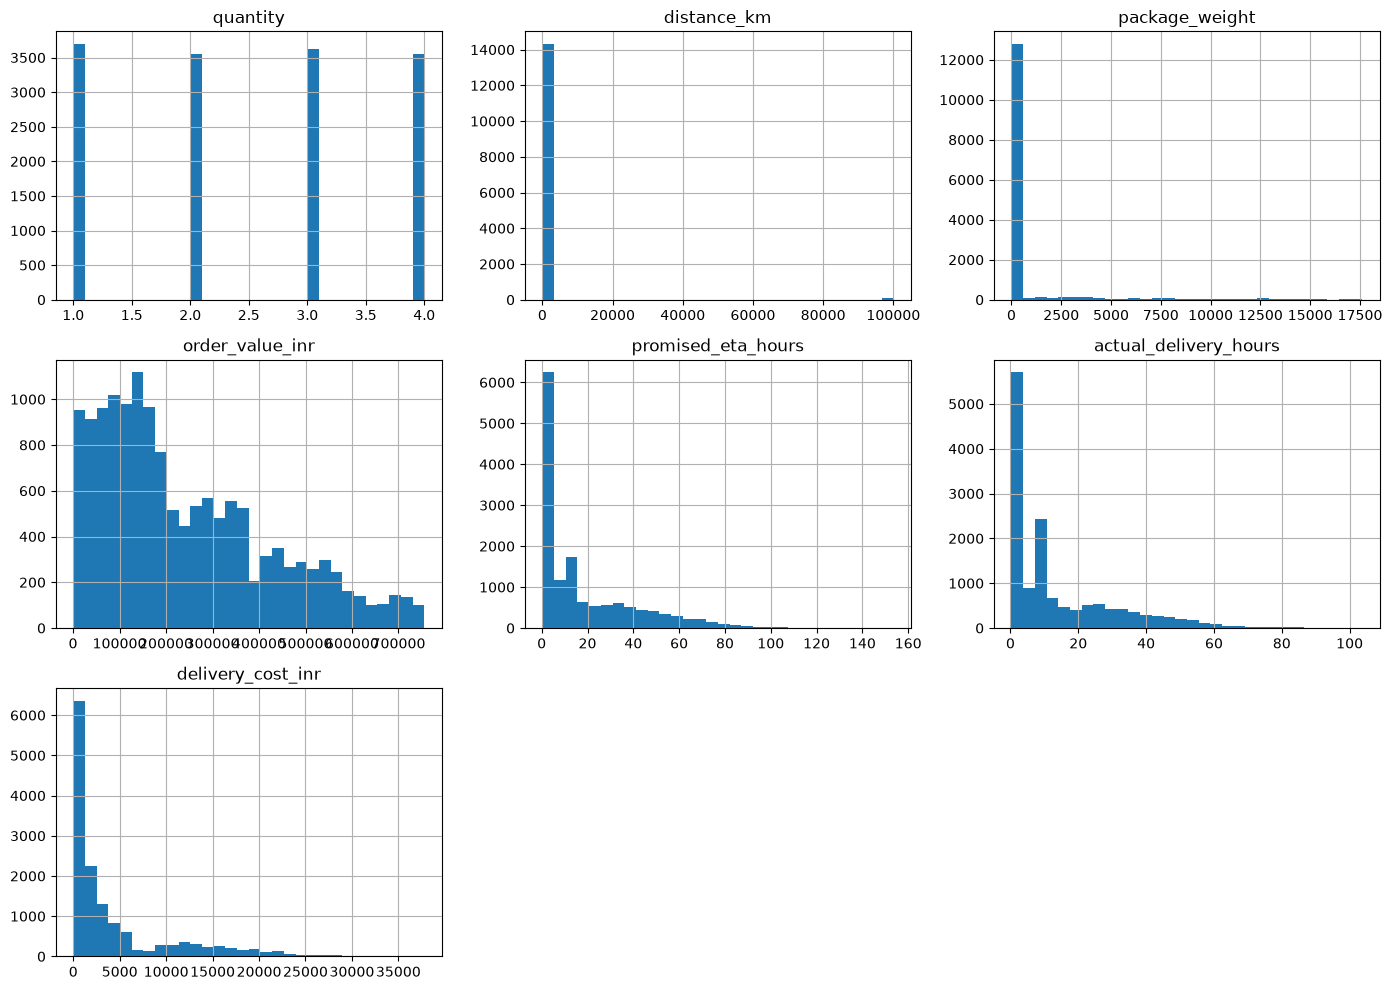

In [13]:
import matplotlib.pyplot as plt

orders[numeric_eda_cols].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

# visualize the important categorical variables

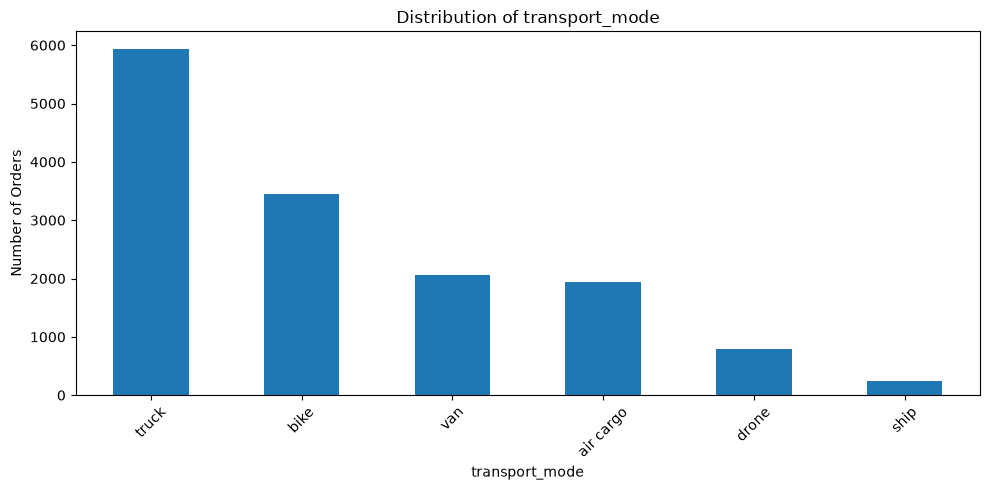

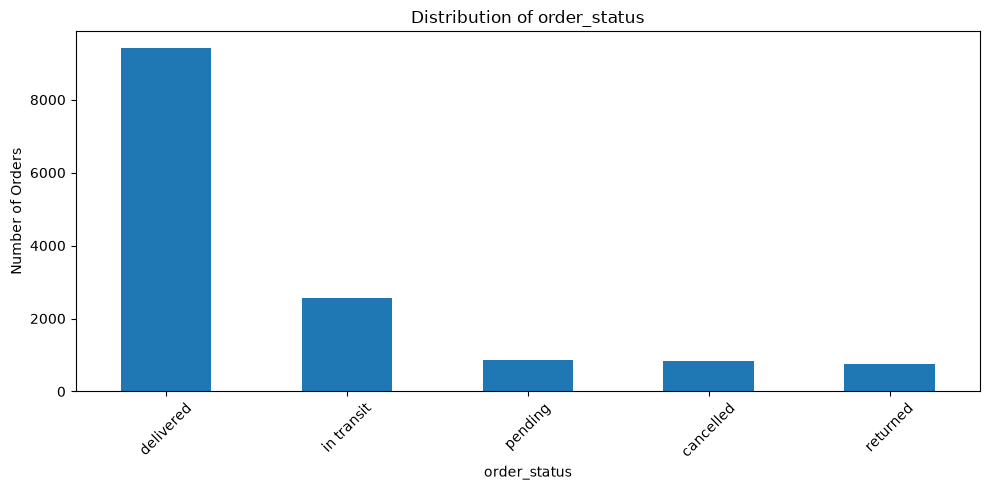

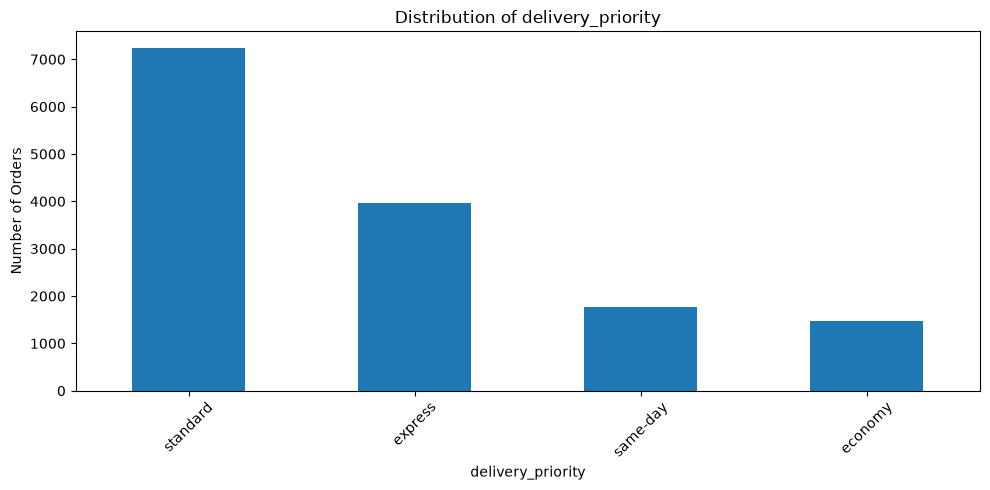

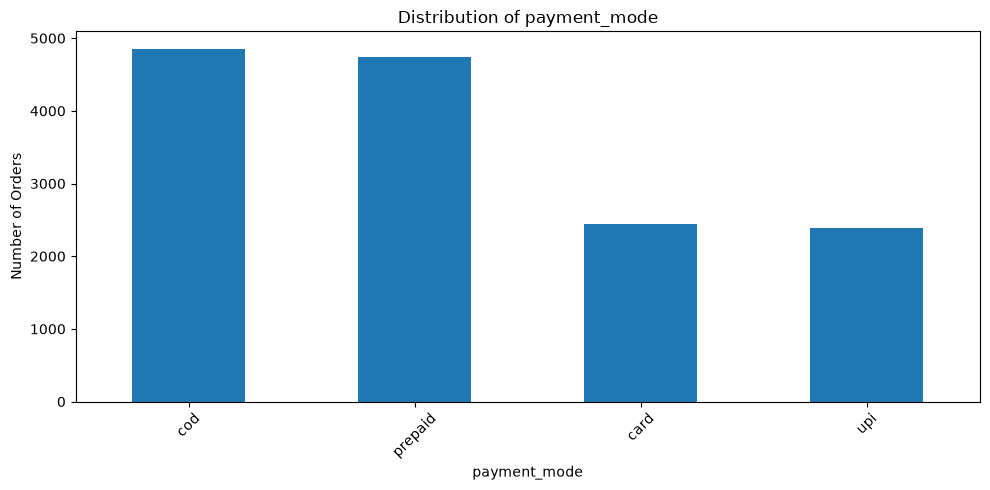

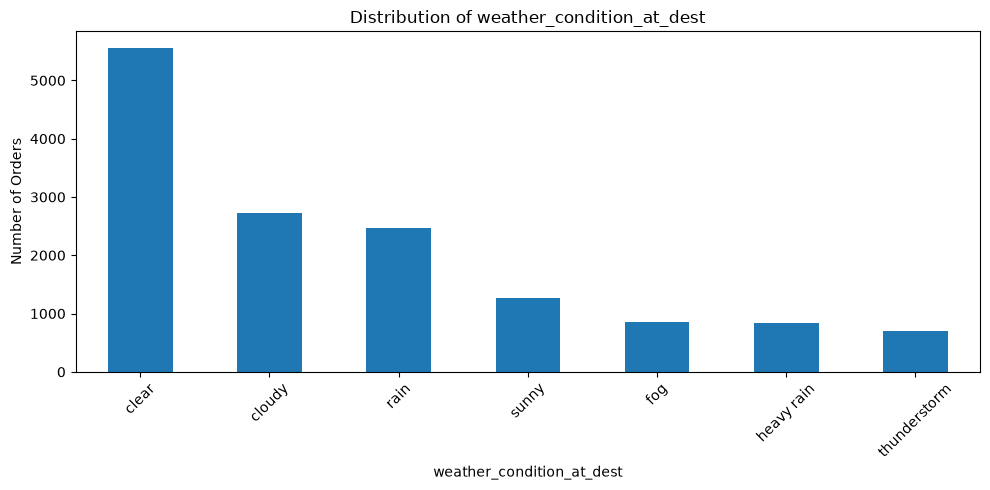

In [14]:
import matplotlib.pyplot as plt


eda_plot_cols = [
    'transport_mode',
    'order_status',
    'delivery_priority',
    'payment_mode',
    'weather_condition_at_dest'
]

for col in eda_plot_cols:
    plt.figure(figsize=(10, 5))
    orders[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Number of Orders')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

transport_mode vs distance_km

In [15]:
orders.groupby('transport_mode')['package_weight'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).sort_values('median', ascending=False)

,count,mean,median,min,max
transport_mode,,,,,
van,2054,198.147064,66.220,0.18,17572.28
ship,246,2714.683659,31.530,0.54,16673.36
truck,5941,1566.062848,16.580,0.20,17623.68
air cargo,1942,105.854511,7.975,0.18,15006.28
bike,3451,25.553008,5.360,0.18,13896.32
drone,793,197.309798,2.480,0.24,17572.28


transport_mode vs order_value_inr

In [16]:
orders.groupby('transport_mode')['order_value_inr'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).sort_values('median', ascending=False)

,count,mean,median,min,max
transport_mode,,,,,
van,2054,260923.712658,228964.72,1487.13,752849.20
ship,246,256715.721382,198457.06,1131.46,748437.16
truck,5941,241929.449017,182727.61,495.71,755385.20
air cargo,1942,237893.539717,176937.70,495.71,755385.20
bike,3451,237782.679134,175931.88,638.72,755385.20
drone,793,207173.110631,160278.54,1131.46,750203.20


In [17]:
orders.groupby('transport_mode')['actual_delivery_hours'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).sort_values('median', ascending=False)

,count,mean,median,min,max
transport_mode,,,,,
ship,246,51.201504,53.075,8.20,102.41
truck,5941,25.714705,24.240,1.84,72.66
air cargo,1942,9.284413,9.125,5.74,13.50
van,2054,4.139377,1.980,0.30,70.69
bike,3451,2.910661,1.300,0.30,103.77
drone,793,4.061160,0.730,0.30,45.81


# delivery_priority vs actual_delivery_hours

In [18]:
orders.groupby('delivery_priority')['actual_delivery_hours'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).sort_values('median')

,count,mean,median,min,max
delivery_priority,,,,,
same-day,1768,9.180781,8.105,0.3,103.77
express,3963,9.310823,8.200,0.3,101.34
standard,7229,17.379777,8.200,0.3,102.41
economy,1467,17.992918,8.980,0.3,101.81


In [19]:
correlation = orders[numerical_eda_cols].corr()

print(correlation.round(2))

                       quantity  distance_km  package_weight  order_value_inr  \
quantity                   1.00        -0.00            0.14             0.58   
distance_km               -0.00         1.00           -0.01             0.00   
package_weight             0.14        -0.01            1.00             0.07   
order_value_inr            0.58         0.00            0.07             1.00   
promised_eta_hours         0.01         0.04            0.10             0.01   
actual_delivery_hours      0.01         0.04            0.10             0.01   
delivery_cost_inr          0.11         0.03            0.63             0.06   

                       promised_eta_hours  actual_delivery_hours  \
quantity                             0.01                   0.01   
distance_km                          0.04                   0.04   
package_weight                       0.10                   0.10   
order_value_inr                      0.01                   0.01   
promised_et

# visualize this correlation matrix as a heatmap

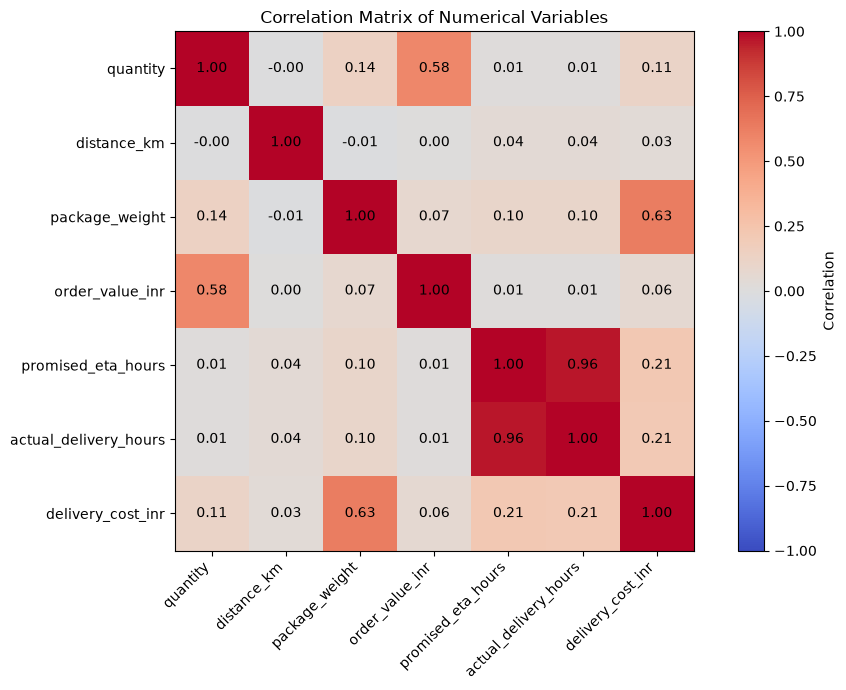

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.imshow(correlation, cmap='coolwarm', vmin=-1, vmax=1)

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j, i,
            f'{correlation.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

# Investigate package_weight

In [21]:
orders['package_weight'].describe()

count    14427.000000
mean       750.606861
std       2476.825094
min          0.180000
25%          3.260000
50%         10.590000
75%         72.060000
max      17623.680000
Name: package_weight, dtype: float64

In [22]:
print("Negative weights:", (orders['package_weight'] < 0).sum())
print("Weights > 1000 kg:", (orders['package_weight'] > 1000).sum())
print("Weights > 10000 kg:", (orders['package_weight'] > 10000).sum())

Negative weights: 0
Weights > 1000 kg: 1566
Weights > 10000 kg: 371


In [23]:
orders.loc[
    (orders['package_weight'] < 0) |
    (orders['package_weight'] > 1000),
    ['order_id', 'quantity', 'package_weight', 'transport_mode', 'order_value_inr']
].head(20)

,order_id,quantity,package_weight,transport_mode,order_value_inr
20,ORD-006048,1,1441.80,truck,18111.90
24,ORD-004895,4,12897.00,truck,705055.84
38,ORD-007420,2,1620.40,truck,8506.06
46,ORD-000108,2,5792.08,truck,139665.76
55,ORD-001580,4,10256.24,truck,116769.44
57,ORD-002601,3,4325.40,truck,54335.70
64,ORD-005641,2,1394.18,air cargo,143966.78
65,ORD-006374,2,2824.78,truck,250387.78
100,ORD-006201,1,3328.18,truck,42099.59
104,ORD-009199,4,14923.48,truck,542472.52


# compare cleaned values with the original raw data

In [24]:
raw_orders = pd.read_csv('../datasets/orders.csv')

suspicious_ids = orders.loc[
    (orders['package_weight'] < 0) |
    (orders['package_weight'] > 1000),
    'order_id'
].head(20)

raw_orders.loc[
    raw_orders['order_id'].isin(suspicious_ids),
    ['order_id', 'package_weight']
]

,order_id,package_weight
22,ORD-006048,1441.8
27,ORD-004895,12897.0
41,ORD-007420,1620.4
49,ORD-000108,5792.08
60,ORD-001580,10256.24
62,ORD-002601,4325.4
69,ORD-005641,1394.18
70,ORD-006374,2824.78
107,ORD-006201,3328.18
111,ORD-009199,14923.48


In [25]:
raw_orders = pd.read_csv('../datasets/orders.csv')

raw_orders[['order_id', 'package_weight']].head(20)

,order_id,package_weight
0,ORD-011545,16.89KG
1,ORD-008131,87540 g
2,ORD-005235,104.66
3,ORD-001394,59.44
4,ORD-011091,96.92
5,ORD-005379,1.54
6,ORD-011641,6080 g
7,ORD-006654,11.58KG
8,ORD-012807,0.59
9,ORD-002865,2.66


In [26]:
raw_orders['package_weight'].astype(str).str.extract(
    r'([a-zA-Z]+)$'
)[0].value_counts(dropna=False)

0
NaN        11092
kg          1874
g           1523
KG          1094
unknown       67
Name: count, dtype: int64

Distance vs actual delivery time

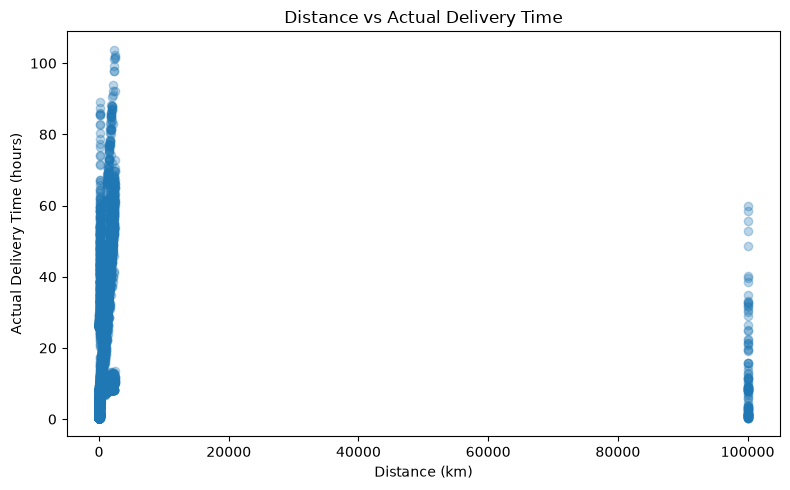

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    orders['distance_km'],
    orders['actual_delivery_hours'],
    alpha=0.3
)

plt.title('Distance vs Actual Delivery Time')
plt.xlabel('Distance (km)')
plt.ylabel('Actual Delivery Time (hours)')

plt.tight_layout()
plt.show()

In [28]:
orders.loc[
    orders['distance_km'] >= 99999,
    ['order_id', 'origin_city', 'destination_city',
     'distance_km', 'transport_mode', 'actual_delivery_hours']
].head(20)

,order_id,origin_city,destination_city,distance_km,transport_mode,actual_delivery_hours
99,ORD-003682,Nagpur,Nagpur,99999.0,bike,1.13
161,ORD-007358,Chennai,Chennai,99999.0,bike,1.14
359,ORD-005323,Lucknow,Lucknow,99999.0,truck,2.86
431,ORD-006829,Coimbatore,Guwahati,99999.0,truck,59.92
898,ORD-004495,Pune,Pune,99999.0,van,2.50
982,ORD-012316,Mumbai,Coimbatore,99999.0,air cargo,11.22
1083,ORD-003629,Delhi,Madurai,99999.0,truck,48.56
1133,ORD-007871,Nagpur,Hyderabad,99999.0,truck,14.83
1156,ORD-013568,Kochi,Madurai,99999.0,bike,8.70
1423,ORD-003363,Kochi,Nagpur,99999.0,air cargo,7.41


In [29]:
print("Distance >= 99999:", (orders['distance_km'] >= 99999).sum())

Distance >= 99999: 117


In [30]:
distance_eda = orders[orders['distance_km'] < 99999]

print("Original rows:", len(orders))
print("Rows used for distance analysis:", len(distance_eda))
print("Excluded placeholder distances:", len(orders) - len(distance_eda))

Original rows: 14427
Rows used for distance analysis: 14310
Excluded placeholder distances: 117


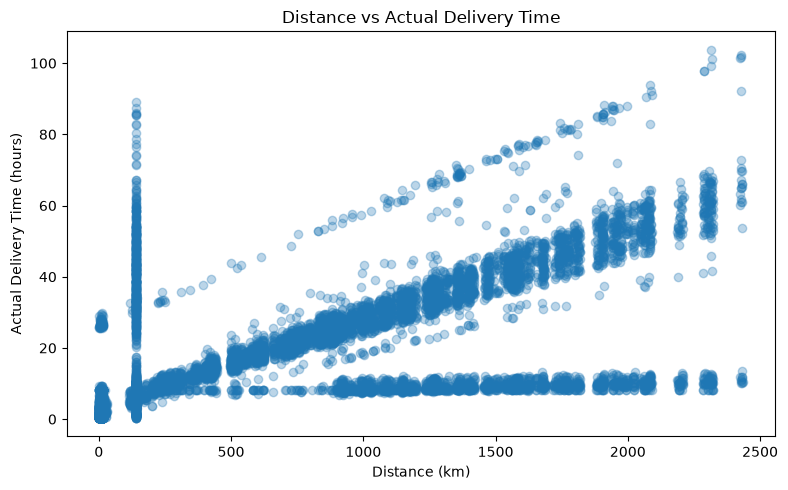

In [31]:
plt.figure(figsize=(8, 5))

plt.scatter(
    distance_eda['distance_km'],
    distance_eda['actual_delivery_hours'],
    alpha=0.3
)

plt.title('Distance vs Actual Delivery Time')
plt.xlabel('Distance (km)')
plt.ylabel('Actual Delivery Time (hours)')

plt.tight_layout()
plt.show()

In [32]:
transport_delivery = orders.groupby('transport_mode')['actual_delivery_hours'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

print(transport_delivery)

                count   mean  median   min     max
transport_mode                                    
air cargo        1942   9.28    9.12  5.74   13.50
bike             3451   2.91    1.30  0.30  103.77
drone             793   4.06    0.73  0.30   45.81
ship              246  51.20   53.08  8.20  102.41
truck            5941  25.71   24.24  1.84   72.66
van              2054   4.14    1.98  0.30   70.69


<Figure size 1000x500 with 0 Axes>

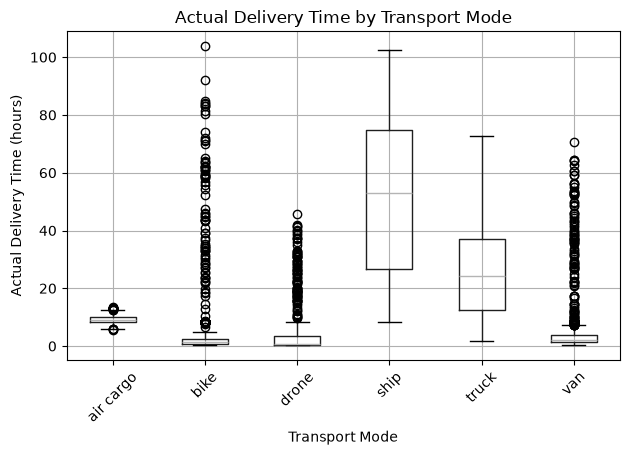

In [33]:
plt.figure(figsize=(10, 5))

orders.boxplot(
    column='actual_delivery_hours',
    by='transport_mode'
)

plt.title('Actual Delivery Time by Transport Mode')
plt.suptitle('')
plt.xlabel('Transport Mode')
plt.ylabel('Actual Delivery Time (hours)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

delivery priority vs actual delivery time.

In [34]:
priority_delivery = orders.groupby('delivery_priority')['actual_delivery_hours'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

print(priority_delivery)

                   count   mean  median  min     max
delivery_priority                                   
economy             1467  17.99    8.98  0.3  101.81
express             3963   9.31    8.20  0.3  101.34
same-day            1768   9.18    8.10  0.3  103.77
standard            7229  17.38    8.20  0.3  102.41


<Figure size 800x500 with 0 Axes>

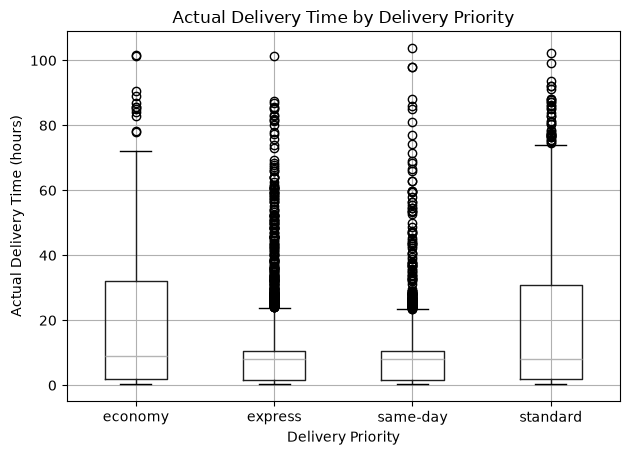

In [35]:
plt.figure(figsize=(8, 5))

orders.boxplot(
    column='actual_delivery_hours',
    by='delivery_priority'
)

plt.title('Actual Delivery Time by Delivery Priority')
plt.suptitle('')
plt.xlabel('Delivery Priority')
plt.ylabel('Actual Delivery Time (hours)')

plt.tight_layout()
plt.show()

In [36]:
print(orders['payment_mode'].value_counts())

payment_mode
cod        4852
prepaid    4738
card       2443
upi        2394
Name: count, dtype: int64


In [37]:
payment_delivery = orders.groupby('payment_mode')['actual_delivery_hours'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

print(payment_delivery)

              count   mean  median  min     max
payment_mode                                   
card           2443  14.13     8.2  0.3   92.13
cod            4852  13.84     8.2  0.3  102.41
prepaid        4738  14.67     8.2  0.3  103.77
upi            2394  14.20     8.2  0.3  101.34


<Figure size 800x500 with 0 Axes>

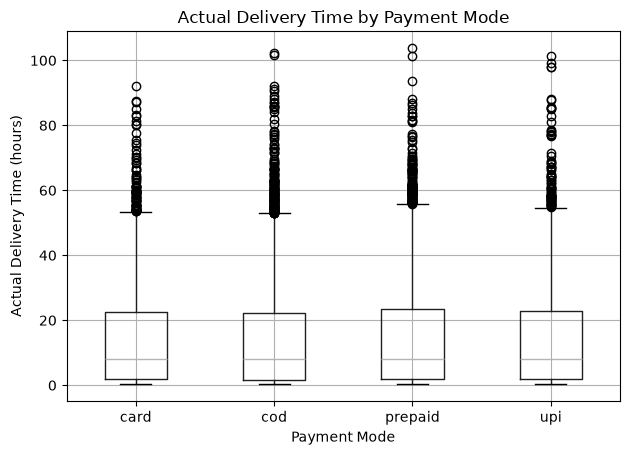

In [38]:
plt.figure(figsize=(8, 5))

orders.boxplot(
    column='actual_delivery_hours',
    by='payment_mode'
)

plt.title('Actual Delivery Time by Payment Mode')
plt.suptitle('')
plt.xlabel('Payment Mode')
plt.ylabel('Actual Delivery Time (hours)')

plt.tight_layout()
plt.show()

Weather condition

In [39]:
orders['weather_condition_at_dest'].value_counts()

weather_condition_at_dest
clear           5564
cloudy          2726
rain            2466
sunny           1265
fog              859
heavy rain       839
thunderstorm     708
Name: count, dtype: int64

In [40]:
weather_delivery = orders.groupby(
    'weather_condition_at_dest'
)['actual_delivery_hours'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

print(weather_delivery)

                           count   mean  median   min     max
weather_condition_at_dest                                    
clear                       5564  13.62    8.20  0.30  103.77
cloudy                      2726  13.74    8.20  0.30   86.96
fog                          859  15.55    8.97  0.47   87.83
heavy rain                   839  15.01    8.20  0.30   81.21
rain                        2466  14.98    8.20  0.57   93.78
sunny                       1265  14.65    8.20  0.30   87.97
thunderstorm                 708  14.81    8.20  0.59  101.24


<Figure size 1000x500 with 0 Axes>

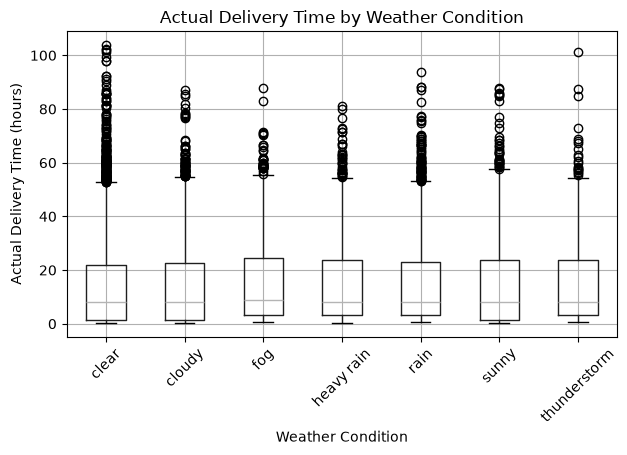

In [41]:
plt.figure(figsize=(10, 5))

orders.boxplot(
    column='actual_delivery_hours',
    by='weather_condition_at_dest'
)

plt.title('Actual Delivery Time by Weather Condition')
plt.suptitle('')
plt.xlabel('Weather Condition')
plt.ylabel('Actual Delivery Time (hours)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [42]:
orders['order_status'].value_counts()

order_status
delivered     9405
in transit    2568
pending        866
cancelled      839
returned       749
Name: count, dtype: int64

In [43]:
status_delivery = orders.groupby('order_status')['actual_delivery_hours'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

print(status_delivery)

              count   mean  median  min     max
order_status                                   
cancelled       839  14.34     8.2  0.3  101.81
delivered      9405  14.25     8.2  0.3  101.34
in transit     2568  14.06     8.2  0.3  103.77
pending         866  14.71     8.2  0.3  102.41
returned        749  13.67     8.2  0.3   77.22


In [44]:
print(
    pd.crosstab(
        orders['order_status'],
        orders['actual_delivery_hours'].isna()
    )
)

actual_delivery_hours  False
order_status                
cancelled                839
delivered               9405
in transit              2568
pending                  866
returned                 749


In [45]:
orders['delivery_delay_hours'] = (
    orders['actual_delivery_hours']
    - orders['promised_eta_hours']
)

print(orders['delivery_delay_hours'].describe().round(2))

count    14427.00
mean        -4.60
std          7.62
min       -115.10
25%         -5.84
50%         -1.66
75%         -0.44
max          7.90
Name: delivery_delay_hours, dtype: float64


In [46]:
print(
    'Late deliveries:',
    (orders['delivery_delay_hours'] > 0).sum()
)

print(
    'On-time deliveries:',
    (orders['delivery_delay_hours'] <= 0).sum()
)

Late deliveries: 303
On-time deliveries: 14124


In [47]:
late_pct = (orders['delivery_delay_hours'] > 0).mean() * 100
on_time_pct = (orders['delivery_delay_hours'] <= 0).mean() * 100

print(f"Late deliveries: {late_pct:.2f}%")
print(f"On-time/early deliveries: {on_time_pct:.2f}%")

Late deliveries: 2.10%
On-time/early deliveries: 97.90%


In [48]:
orders.loc[
    orders['delivery_delay_hours'] < -24,
    [
        'order_id',
        'promised_eta_hours',
        'actual_delivery_hours',
        'delivery_delay_hours',
        'transport_mode',
        'order_status'
    ]
].sort_values('delivery_delay_hours').head(10)

,order_id,promised_eta_hours,actual_delivery_hours,delivery_delay_hours,transport_mode,order_status
8424,ORD-007561,123.3,8.2,-115.1,ship,returned
6542,ORD-003652,117.3,8.2,-109.1,ship,in transit
13288,ORD-001578,103.2,8.2,-95.0,ship,delivered
11310,ORD-006701,100.6,8.2,-92.4,truck,cancelled
5984,ORD-008365,98.5,8.2,-90.3,bike,cancelled
13799,ORD-007612,98.3,8.2,-90.1,van,in transit
13436,ORD-008461,91.0,8.2,-82.8,truck,cancelled
13800,ORD-008461,91.0,8.2,-82.8,truck,cancelled
12763,ORD-000009,84.6,8.2,-76.4,truck,delivered
4696,ORD-010868,83.3,8.2,-75.1,truck,returned


In [49]:
print(
    'Delays below -24 hours:',
    (orders['delivery_delay_hours'] < -24).sum()
)

Delays below -24 hours: 383


In [50]:
print((orders['actual_delivery_hours'] == 8.2).sum())

620


In [51]:
print(
    orders.loc[
        (orders['delivery_delay_hours'] < -24) &
        (orders['actual_delivery_hours'] != 8.2),
        ['order_id', 'promised_eta_hours', 'actual_delivery_hours',
         'delivery_delay_hours', 'transport_mode', 'order_status']
    ].sort_values('delivery_delay_hours').head(20)
)

         order_id  promised_eta_hours  actual_delivery_hours  \
5159   ORD-010892               149.5                  97.86   
12823  ORD-010892               149.5                  97.86   
8370   ORD-005320               151.8                 101.34   
6394   ORD-004433               153.5                 103.77   
12922  ORD-001692               140.2                  90.57   
2060   ORD-005553               136.0                  88.18   
902    ORD-002129               137.0                  92.13   
7828   ORD-014475               142.2                  99.31   
10049  ORD-007005               123.6                  81.21   
696    ORD-007859               121.6                  80.49   
5324   ORD-007552               142.1                 101.24   
4513   ord-013640               125.5                  84.95   
10269  ORD-002483               116.9                  76.85   
8975   ORD-005313               121.3                  81.45   
8172   ORD-014628               122.9   

In [52]:
print(orders['order_id'].duplicated().sum())

184


# 2. customers

In [53]:
customers = pd.read_csv("../cleaned_data/customers_cleaned.csv")

print(customers.shape)
print(customers.info())
print(customers.isna().sum())
print("Duplicate rows:", customers.duplicated().sum())

(5000, 12)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       5000 non-null   str    
 1   customer_name     4980 non-null   str    
 2   email             5000 non-null   str    
 3   phone             4915 non-null   str    
 4   city              5000 non-null   str    
 5   state             5000 non-null   str    
 6   pincode           5000 non-null   int64  
 7   signup_date       5000 non-null   str    
 8   customer_segment  5000 non-null   str    
 9   is_prime_member   5000 non-null   str    
 10  lifetime_orders   5000 non-null   float64
 11  avg_rating_given  5000 non-null   float64
dtypes: float64(2), int64(1), str(9)
memory usage: 893.2 KB
None
customer_id          0
customer_name       20
email                0
phone               85
city                 0
state                0
pincode              0
signup_da

In [54]:
print("Customer segment:")
print(customers['customer_segment'].value_counts())

print("\nPrime member:")
print(customers['is_prime_member'].value_counts())

print("\nState:")
print(customers['state'].value_counts())

print("\nCity - top 20:")
print(customers['city'].value_counts().head(20))

Customer segment:
customer_segment
Business      1671
Retail        1633
SMB            892
Enterprise     804
Name: count, dtype: int64

Prime member:
is_prime_member
No     2528
Yes    2472
Name: count, dtype: int64

State:
state
TN    777
MH    758
KA    494
OD    272
KL    266
DL    262
AP    261
CH    261
AS    250
UP    247
GJ    238
HR    234
TS    234
RJ    234
WB    212
Name: count, dtype: int64

City - top 20:
city
Madurai          257
Bhubaneswar      256
Kochi            254
Delhi            252
Mysuru           250
Visakhapatnam    250
Nagpur           246
Chennai          246
Chandigarh       246
Pune             239
Coimbatore       239
Guwahati         234
Mumbai           233
Lucknow          232
Ahmedabad        226
Jaipur           225
Hyderabad        223
Gurugram         222
Bengaluru        216
Kolkata          209
Name: count, dtype: int64


In [55]:
print(customers[['lifetime_orders', 'avg_rating_given']].describe().round(2))

       lifetime_orders  avg_rating_given
count          5000.00           5000.00
mean            119.61              3.49
std              68.44              0.83
min               1.00              2.00
25%              62.00              2.80
50%             120.00              3.50
75%             178.00              4.20
max             240.00              5.00


In [56]:
print("Customer segment:")
print(customers['customer_segment'].value_counts())

print("\nPrime member:")
print(customers['is_prime_member'].value_counts())

Customer segment:
customer_segment
Business      1671
Retail        1633
SMB            892
Enterprise     804
Name: count, dtype: int64

Prime member:
is_prime_member
No     2528
Yes    2472
Name: count, dtype: int64


# Customer segment vs lifetime orders

In [57]:
customers.groupby('customer_segment')['lifetime_orders'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

,count,mean,median,min,max
customer_segment,,,,,
Business,1671,124.20,125.0,1.0,240.0
Enterprise,804,115.53,115.5,1.0,240.0
Retail,1633,119.63,120.0,1.0,240.0
SMB,892,114.64,116.0,1.0,240.0


# Prime membership vs lifetime orders and rating

In [58]:
customers.groupby('is_prime_member')[
    ['lifetime_orders', 'avg_rating_given']
].agg(
    ['mean', 'median']
).round(2)

lifetime_orders        avg_rating_given       
                           mean median             mean median
is_prime_member                                               
No                       120.24  120.0             3.49    3.5
Yes                      118.96  120.0             3.49    3.5

# visualizations 

1. Customer segment distribution

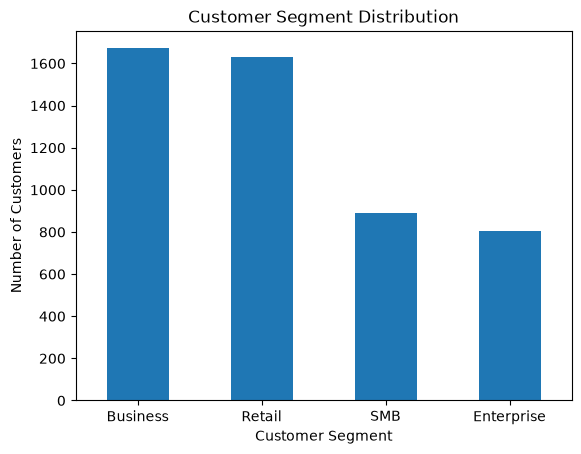

In [59]:
import matplotlib.pyplot as plt

customers['customer_segment'].value_counts().plot(kind='bar')

plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

2. Lifetime orders by customer segment

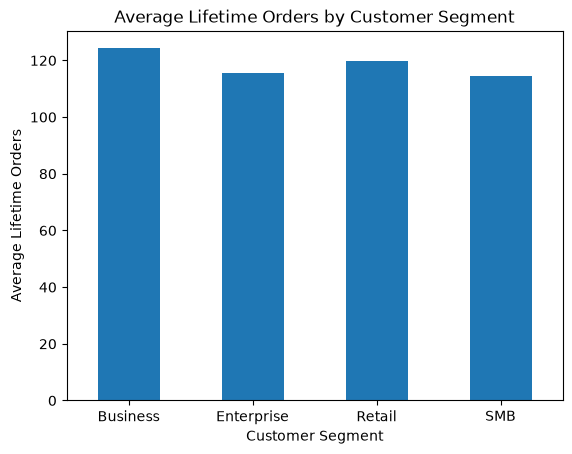

In [60]:
customers.groupby('customer_segment')['lifetime_orders'].mean().plot(kind='bar')

plt.title('Average Lifetime Orders by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Lifetime Orders')
plt.xticks(rotation=0)
plt.show()

3. Prime vs non-prime lifetime orders

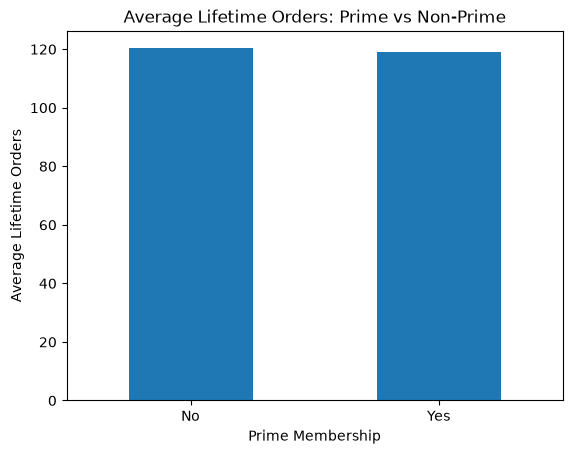

In [61]:
customers.groupby('is_prime_member')['lifetime_orders'].mean().plot(kind='bar')

plt.title('Average Lifetime Orders: Prime vs Non-Prime')
plt.xlabel('Prime Membership')
plt.ylabel('Average Lifetime Orders')
plt.xticks(rotation=0)
plt.show()

# 3. delivery_logs

In [62]:
delivery_logs = pd.read_csv("../cleaned_data/delivery_logs_clean.csv")

print(delivery_logs.shape)
print(delivery_logs.info())
print(delivery_logs.isna().sum())
print("Duplicate rows:", delivery_logs.duplicated().sum())

(78756, 11)
<class 'pandas.DataFrame'>
RangeIndex: 78756 entries, 0 to 78755
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   log_id           78756 non-null  str    
 1   order_id         78756 non-null  str    
 2   event_seq        76356 non-null  float64
 3   event_type       78756 non-null  str    
 4   event_timestamp  77135 non-null  str    
 5   hub_code         78756 non-null  str    
 6   vehicle_id       78756 non-null  str    
 7   scanned_by_emp   78756 non-null  str    
 8   location_city    78756 non-null  str    
 9   remarks          78756 non-null  str    
 10  exception_code   78756 non-null  str    
dtypes: float64(1), str(10)
memory usage: 15.8 MB
None
log_id                0
order_id              0
event_seq          2400
event_type            0
event_timestamp    1621
hub_code              0
vehicle_id            0
scanned_by_emp        0
location_city         0
remarks              

In [63]:
# Check event types

print(delivery_logs['event_type'].value_counts())


event_type
ORDER_PLACED        15000
PICKED_UP           15000
DELIVERED           12773
AT_HUB              11295
IN_TRANSIT          11250
OUT_FOR_DELIVERY    11211
FAILED_ATTEMPT       1314
RTO_INITIATED         913
Name: count, dtype: int64


In [64]:
# Check exception codes

print(delivery_logs['exception_code'].value_counts())

exception_code
NO_EXCEPTION    67097
EX-01            4619
EX-07            3920
EX-12            3120
Name: count, dtype: int64


In [65]:
# Check event sequence

print(delivery_logs['event_seq'].describe())

count    76356.000000
mean         3.189153
std          1.591251
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          6.000000
Name: event_seq, dtype: float64


In [66]:
# Check duplicate log_id

print("Duplicate log_id:", delivery_logs['log_id'].duplicated().sum())

Duplicate log_id: 0


In [67]:
duplicate_logs = delivery_logs[
    delivery_logs.duplicated(keep=False)
]

print(duplicate_logs.shape)
print(duplicate_logs.head(20))

(0, 11)
Empty DataFrame
Columns: [log_id, order_id, event_seq, event_type, event_timestamp, hub_code, vehicle_id, scanned_by_emp, location_city, remarks, exception_code]
Index: []


# Check the duplicate log IDs

In [68]:
duplicate_log_ids = delivery_logs[
    delivery_logs['log_id'].duplicated(keep=False)
]

print(duplicate_log_ids.shape)
print(duplicate_log_ids['log_id'].nunique())

(0, 11)


0


In [69]:
delivery_logs = pd.read_csv(
    "../cleaned_data/delivery_logs_clean.csv"
)

print(delivery_logs.shape)
print(delivery_logs.isna().sum())

(78756, 11)
log_id                0
order_id              0
event_seq          2400
event_type            0
event_timestamp    1621
hub_code              0
vehicle_id            0
scanned_by_emp        0
location_city         0
remarks               0
exception_code        0
dtype: int64


In [70]:
print(delivery_logs['event_seq'].value_counts(dropna=False).sort_index())

event_seq
1.0    14540
2.0    14573
3.0    14543
4.0    14528
5.0    10948
6.0     7224
NaN     2400
Name: count, dtype: int64


In [71]:
print(delivery_logs['event_timestamp'].isna().sum())

1621


In [72]:
print(
    delivery_logs.groupby('event_type')['event_seq']
    .apply(lambda x: x.isna().sum())
)

event_type
AT_HUB              366
DELIVERED           381
FAILED_ATTEMPT       41
IN_TRANSIT          330
ORDER_PLACED        460
OUT_FOR_DELIVERY    360
PICKED_UP           427
RTO_INITIATED        35
Name: event_seq, dtype: int64


# visualization

Event type distribution

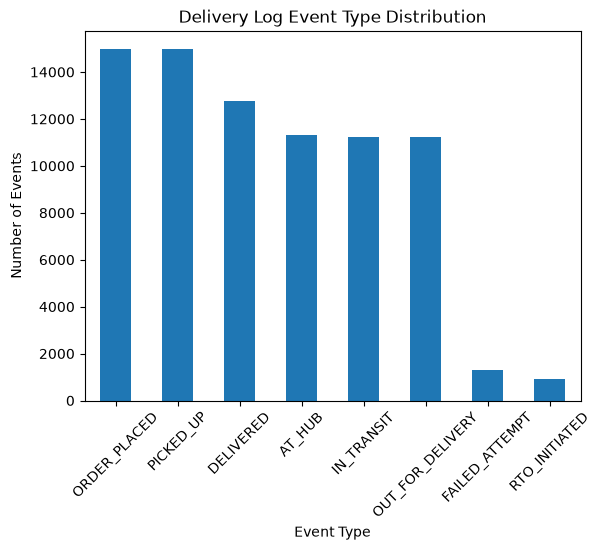

In [73]:
import matplotlib.pyplot as plt

delivery_logs['event_type'].value_counts().plot(kind='bar')

plt.title('Delivery Log Event Type Distribution')
plt.xlabel('Event Type')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.show()

delivery exceptions

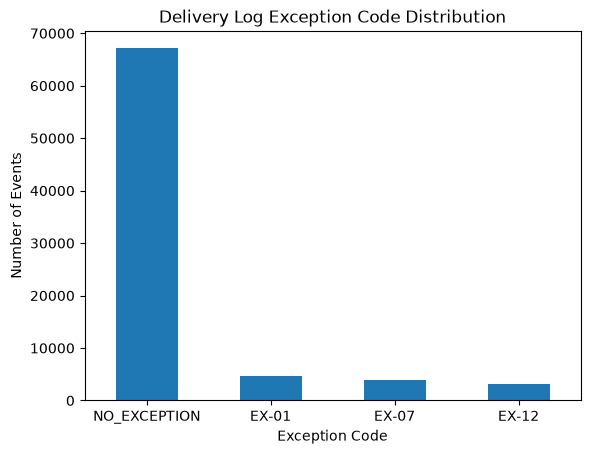

In [74]:
delivery_logs['exception_code'].value_counts().plot(kind='bar')

plt.title('Delivery Log Exception Code Distribution')
plt.xlabel('Exception Code')
plt.ylabel('Number of Events')
plt.xticks(rotation=0)
plt.show()

Hub distribution

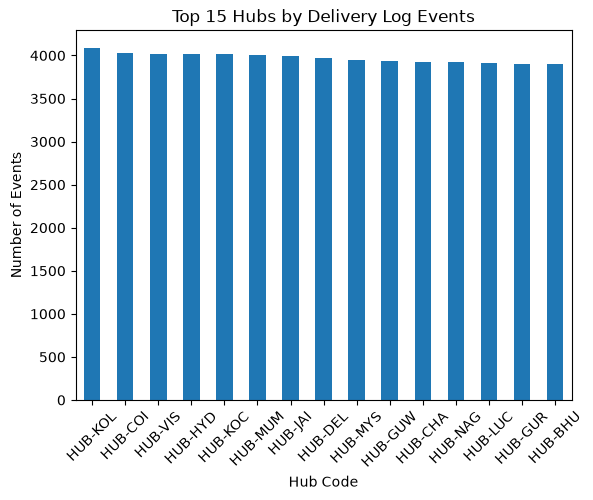

In [75]:
delivery_logs['hub_code'].value_counts().head(15).plot(kind='bar')

plt.title('Top 15 Hubs by Delivery Log Events')
plt.xlabel('Hub Code')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.show()

Event sequence distribution

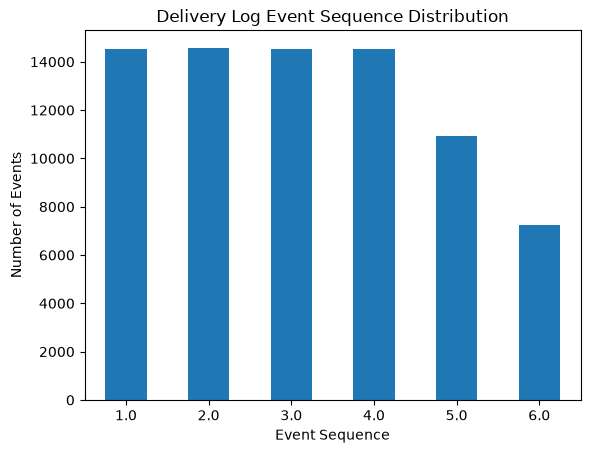

In [76]:
delivery_logs['event_seq'].value_counts().sort_index().plot(kind='bar')

plt.title('Delivery Log Event Sequence Distribution')
plt.xlabel('Event Sequence')
plt.ylabel('Number of Events')
plt.xticks(rotation=0)
plt.show()

# 4. drone_telemetry.csv

In [77]:
drone_telemetry = pd.read_csv(
    "../cleaned_data/drone_telemetry_cleaned.csv"
)

print(drone_telemetry.shape)
print(drone_telemetry.info())
print(drone_telemetry.isna().sum())
print("Duplicate rows:", drone_telemetry.duplicated().sum())

(41929, 19)
<class 'pandas.DataFrame'>
RangeIndex: 41929 entries, 0 to 41928
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   flight_id                41929 non-null  str    
 1   drone_id                 41929 non-null  str    
 2   flight_timestamp         41076 non-null  str    
 3   flight_duration_min      40677 non-null  float64
 4   cumulative_flight_hours  41929 non-null  float64
 5   battery_cycles           41929 non-null  int64  
 6   battery_start_pct        41929 non-null  float64
 7   battery_end_pct          40217 non-null  float64
 8   battery_health_pct       41929 non-null  float64
 9   motor_temp_c             41929 non-null  float64
 10  vibration_rms            39789 non-null  float64
 11  payload_kg               41929 non-null  float64
 12  max_altitude_m           41929 non-null  float64
 13  wind_speed_kmph          41929 non-null  float64
 14  gps_signal_quality   

# numeric EDA

In [78]:
drone_telemetry[
    [
        'flight_duration_min',
        'cumulative_flight_hours',
        'battery_cycles',
        'battery_start_pct',
        'battery_end_pct',
        'battery_health_pct',
        'motor_temp_c',
        'vibration_rms',
        'payload_kg',
        'max_altitude_m',
        'wind_speed_kmph',
        'rotor_rpm_avg',
        'route_deviation_m'
    ]
].describe().round(2)

,flight_duration_min,cumulative_flight_hours,battery_cycles,battery_start_pct,battery_end_pct,battery_health_pct,motor_temp_c,vibration_rms,payload_kg,max_altitude_m,wind_speed_kmph,rotor_rpm_avg,route_deviation_m
count,40677.00,41929.00,41929.00,41929.00,40217.00,41929.00,41929.00,39789.00,41929.00,41929.00,41929.00,40628.00,41929.00
mean,20.93,500.17,1049.86,95.67,35.36,62.81,77.40,2.69,3.01,94.77,21.03,6201.72,17.17
std,9.77,255.36,536.26,3.46,27.02,15.79,10.25,0.74,1.61,37.44,12.10,398.33,10.85
min,4.00,24.26,50.00,78.60,2.00,40.00,42.60,0.32,0.20,30.00,0.00,4553.00,0.00
25%,12.50,273.47,574.00,93.30,6.70,49.50,70.10,2.15,1.61,62.50,10.70,5936.00,8.60
50%,20.90,511.58,1074.00,96.00,34.00,61.60,77.30,2.68,3.02,94.90,21.00,6200.00,16.10
75%,29.40,701.29,1472.00,98.70,58.90,76.90,84.70,3.22,4.40,127.00,31.50,6468.00,24.20
max,38.00,1002.49,2105.00,100.00,92.80,97.70,114.10,5.30,5.80,160.00,42.00,7808.00,73.00


# categorical columns

In [79]:
print("GPS signal quality:")
print(drone_telemetry['gps_signal_quality'].value_counts(dropna=False))

print("\nError codes:")
print(drone_telemetry['error_codes'].value_counts(dropna=False))

print("\nMaintenance required:")
print(drone_telemetry['maintenance_required'].value_counts(dropna=False))

GPS signal quality:
gps_signal_quality
Good    25097
Fair     8469
Poor     8363
Name: count, dtype: int64

Error codes:
error_codes
NaN                           24483
E-BATT                         8494
E-THERM;E-VIB                  1862
E-THERM                        1753
E-THERM;E-VIB;E-BATT           1628
E-THERM;E-BATT                 1250
E-GPS                           773
E-VIB                           763
E-VIB;E-BATT                    471
E-BATT;E-GPS                    239
E-THERM;E-VIB;E-GPS              54
E-THERM;E-VIB;E-BATT;E-GPS       44
E-THERM;E-GPS                    43
E-THERM;E-BATT;E-GPS             35
E-VIB;E-GPS                      26
E-VIB;E-BATT;E-GPS               11
Name: count, dtype: int64

Maintenance required:
maintenance_required
0    37276
1     4653
Name: count, dtype: int64


# battery consistency

In [80]:
battery_increase = drone_telemetry[
    drone_telemetry['battery_end_pct'] >
    drone_telemetry['battery_start_pct']
]

print("Battery increase records:", len(battery_increase))

battery_increase[
    [
        'flight_id',
        'drone_id',
        'battery_start_pct',
        'battery_end_pct',
        'flight_duration_min'
    ]
].head(20)

Battery increase records: 0


,flight_id,drone_id,battery_start_pct,battery_end_pct,flight_duration_min


In [81]:
print(
    drone_telemetry[
        'battery_start_pct'
    ].isna().sum(),
    drone_telemetry[
        'battery_end_pct'
    ].isna().sum()
)

0 1712


# motor temperature

In [82]:
high_temp = drone_telemetry[
    drone_telemetry['motor_temp_c'] > 100
]

print("Motor temperature > 100°C:", len(high_temp))

high_temp[
    [
        'flight_id',
        'drone_id',
        'motor_temp_c',
        'flight_duration_min',
        'battery_health_pct',
        'vibration_rms',
        'wind_speed_kmph',
        'error_codes',
        'maintenance_required'
    ]
].head(10)

Motor temperature > 100°C: 469


,flight_id,drone_id,motor_temp_c,flight_duration_min,battery_health_pct,vibration_rms,wind_speed_kmph,error_codes,maintenance_required
27,FLT-0034257,VEH-0114,102.200000,6.8,43.3,4.041,40.8,E-THERM;E-VIB,1
245,FLT-0031235,VEH-0104,102.500000,33.4,40.0,4.384,40.9,E-THERM;E-VIB;E-BATT,1
263,FLT-0008735,VEH-0029,107.400000,24.0,40.0,4.059,36.3,E-THERM;E-VIB;E-BATT;E-GPS,1
447,FLT-0023688,VEH-0079,100.833333,35.6,41.3,4.027,39.2,E-THERM;E-VIB;E-BATT,1
459,FLT-0001461,VEH-0005,106.100000,16.2,40.0,4.249,39.2,E-THERM;E-VIB,1
757,FLT-0031166,VEH-0104,104.800000,10.2,40.0,4.245,40.3,E-THERM;E-VIB,1
790,FLT-0008842,VEH-0029,102.600000,31.6,40.0,4.272,39.1,E-THERM;E-VIB;E-BATT,1
804,FLT-0022201,VEH-0074,100.200000,37.7,74.2,4.858,32.8,E-THERM;E-VIB;E-BATT,1
1037,FLT-0009489,VEH-0031,102.500000,22.5,47.5,4.406,19.6,E-THERM;E-VIB,1
1051,FLT-0023084,VEH-0077,100.900000,20.2,40.0,4.270,28.5,E-THERM;E-VIB,1


In [83]:
print(
    drone_telemetry[
        'motor_temp_c'
    ].describe().round(2)
)

count    41929.00
mean        77.40
std         10.25
min         42.60
25%         70.10
50%         77.30
75%         84.70
max        114.10
Name: motor_temp_c, dtype: float64


In [84]:
drone_telemetry.groupby('maintenance_required')['motor_temp_c'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

,count,mean,median,min,max
maintenance_required,,,,,
0,37276,75.52,75.8,42.6,102.1
1,4653,92.42,92.9,53.6,114.1


In [85]:
pd.crosstab(
    drone_telemetry['maintenance_required'],
    drone_telemetry['motor_temp_c'] > 100,
    normalize='index'
).round(4) * 100

motor_temp_c,False,True
maintenance_required,,
0,99.99,0.01
1,90.01,9.99


# visualization

1. Drone telemetry

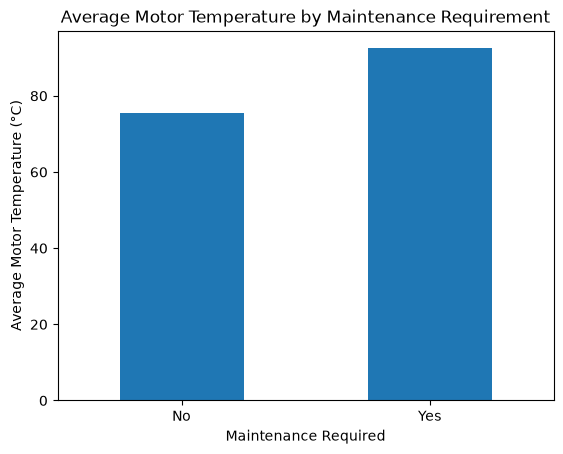

In [86]:
drone_telemetry.groupby('maintenance_required')['motor_temp_c'].mean().plot(
    kind='bar'
)

plt.title('Average Motor Temperature by Maintenance Requirement')
plt.xlabel('Maintenance Required')
plt.ylabel('Average Motor Temperature (°C)')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.show()

2.GPS quality vs maintenance

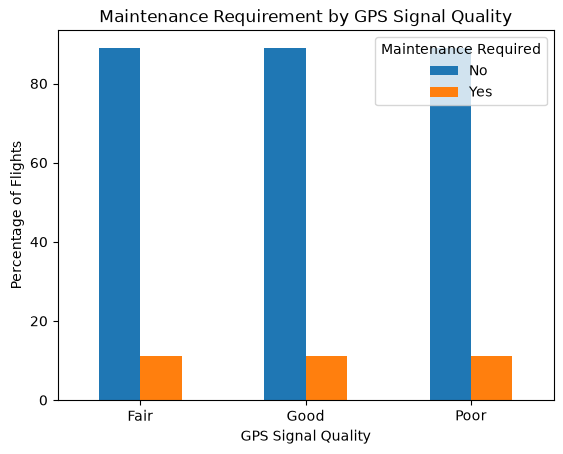

In [87]:
gps_maintenance = pd.crosstab(
    drone_telemetry['gps_signal_quality'],
    drone_telemetry['maintenance_required'],
    normalize='index'
) * 100

gps_maintenance.plot(kind='bar')

plt.title('Maintenance Requirement by GPS Signal Quality')
plt.xlabel('GPS Signal Quality')
plt.ylabel('Percentage of Flights')
plt.xticks(rotation=0)
plt.legend(title='Maintenance Required', labels=['No', 'Yes'])
plt.show()

3. Battery health vs maintenance

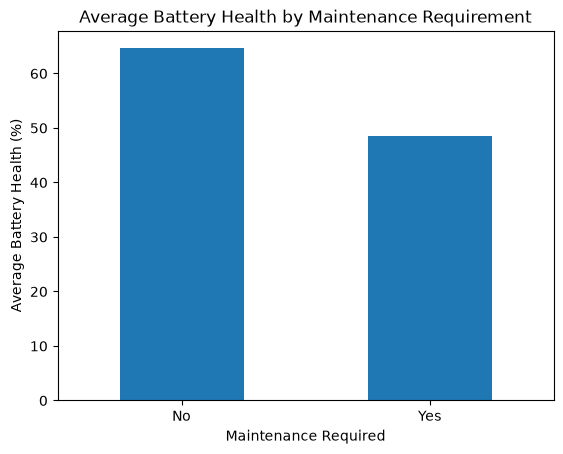

In [88]:
drone_telemetry.groupby('maintenance_required')['battery_health_pct'].mean().plot(
    kind='bar'
)

plt.title('Average Battery Health by Maintenance Requirement')
plt.xlabel('Maintenance Required')
plt.ylabel('Average Battery Health (%)')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.show()

In [89]:
error_maintenance = pd.crosstab(
    drone_telemetry['error_codes'].fillna('No Error'),
    drone_telemetry['maintenance_required'],
    normalize='index'
) * 100

error_maintenance['maintenance_rate'] = error_maintenance.get(1, 0)

error_maintenance.sort_values(
    'maintenance_rate',
    ascending=False
).head(10)

maintenance_required,0,1,maintenance_rate
error_codes,,,
E-THERM;E-VIB;E-BATT,20.884521,79.115479,79.115479
E-THERM;E-VIB,21.911923,78.088077,78.088077
E-THERM;E-VIB;E-GPS,24.074074,75.925926,75.925926
E-THERM;E-VIB;E-BATT;E-GPS,29.545455,70.454545,70.454545
E-VIB;E-BATT;E-GPS,63.636364,36.363636,36.363636
E-THERM,70.964062,29.035938,29.035938
E-THERM;E-BATT,71.040000,28.960000,28.960000
E-THERM;E-BATT;E-GPS,71.428571,28.571429,28.571429
E-VIB,73.001311,26.998689,26.998689


In [90]:
drone_telemetry['error_codes'].isna().sum()

np.int64(24483)

# 5. fleet_vehicles_cleaned.csv


In [91]:
fleet_vehicles = pd.read_csv("../cleaned_data/fleet_vehicles_cleaned.csv")

print(fleet_vehicles.shape)
print(fleet_vehicles.info())
print(fleet_vehicles.isna().sum())
print("Duplicate rows:", fleet_vehicles.duplicated().sum())

(736, 15)
<class 'pandas.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   vehicle_id           736 non-null    str    
 1   vehicle_type         736 non-null    str    
 2   model_name           736 non-null    str    
 3   capacity_kg          736 non-null    float64
 4   max_range_km         736 non-null    float64
 5   avg_speed_kmph       736 non-null    int64  
 6   hub_code             736 non-null    str    
 7   purchase_date        736 non-null    str    
 8   odometer_km          700 non-null    float64
 9   fleet_status         736 non-null    str    
 10  driver_id            596 non-null    str    
 11  battery_capacity_wh  140 non-null    float64
 12  last_service_date    736 non-null    str    
 13  insurance_expiry     736 non-null    str    
 14  ownership            736 non-null    str    
dtypes: float64(4), int64(1), str(10)
memory u

Understand the fleet

Numeric summary

In [92]:
fleet_vehicles[
    [
        'capacity_kg',
        'max_range_km',
        'avg_speed_kmph',
        'odometer_km',
        'battery_capacity_wh'
    ]
].describe().round(2)

,capacity_kg,max_range_km,avg_speed_kmph,odometer_km,battery_capacity_wh
count,736.00,736.00,736.00,700.00,140.00
mean,11161.35,597.08,62.35,128163.84,5384.35
std,68283.49,1627.14,108.78,75593.20,1934.36
min,1.00,-5166.20,26.00,878.20,2016.00
25%,13.48,49.20,35.00,59060.15,3756.50
50%,31.85,104.75,45.00,128437.85,5445.00
75%,1094.18,351.08,52.00,193413.22,6824.75
max,842658.10,13930.20,686.00,259612.50,8978.00


In [93]:
print(fleet_vehicles['vehicle_type'].value_counts())

vehicle_type
Bike         260
Van          180
Drone        140
Truck        120
Air Cargo     22
Ship          14
Name: count, dtype: int64


In [94]:
# Fleet status and ownership

print("Fleet status:")
print(fleet_vehicles['fleet_status'].value_counts())

print("\nOwnership:")
print(fleet_vehicles['ownership'].value_counts())

Fleet status:
fleet_status
Active         283
Maintenance    168
Retired        106
Idle           104
In Service      75
Name: count, dtype: int64

Ownership:
ownership
Owned          249
3PL Partner    247
Leased         240
Name: count, dtype: int64


Check suspicious values by vehicle type

In [95]:
print("Capacity by vehicle type:")
print(
    fleet_vehicles.groupby('vehicle_type')['capacity_kg']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)

print("\nRange by vehicle type:")
print(
    fleet_vehicles.groupby('vehicle_type')['max_range_km']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)

print("\nSpeed by vehicle type:")
print(
    fleet_vehicles.groupby('vehicle_type')['avg_speed_kmph']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)

print("\nBattery capacity by vehicle type:")
print(
    fleet_vehicles.groupby('vehicle_type')['battery_capacity_wh']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)

Capacity by vehicle type:
              count       mean     median       min       max
vehicle_type                                                 
Air Cargo        22   27108.97   27417.35    9924.4   44040.3
Bike            260      21.82      21.20      10.0      34.9
Drone           140       3.66       3.80       1.0       6.0
Ship             14  436783.39  456751.10  114321.3  842658.1
Truck           120   11277.99   11703.55    3129.7   17899.3
Van             180     799.13     784.55     400.3    1189.0

Range by vehicle type:
              count      mean    median     min      max
vehicle_type                                            
Air Cargo        22   3644.96   3651.40 -5166.2   5933.8
Bike            260     77.22     81.15   -88.7    119.9
Drone           140     17.84     17.65   -20.6     29.9
Ship             14  10176.30  10509.75  3626.4  13930.2
Truck           120   1225.51   1199.90 -1447.8   2198.9
Van             180    262.00    273.35  -343.7    398.

Investigate the negative ranges

In [96]:
negative_range = fleet_vehicles[
    fleet_vehicles['max_range_km'] < 0
]

print("Negative max_range values:", negative_range.shape[0])

print(
    negative_range[
        [
            'vehicle_id',
            'vehicle_type',
            'max_range_km',
            'capacity_kg',
            'avg_speed_kmph',
            'fleet_status'
        ]
    ].sort_values('max_range_km').head(20)
)

Negative max_range values: 15
    vehicle_id vehicle_type  max_range_km  capacity_kg  avg_speed_kmph  \
705   VEH-0706    Air Cargo       -5166.2      10670.6             684   
693   VEH-0694        Truck       -1447.8      10537.2              54   
619   VEH-0620        Truck       -1122.1      13700.7              47   
653   VEH-0654        Truck       -1078.1      11554.6              50   
473   VEH-0474          Van        -343.7       1103.0              45   
567   VEH-0568          Van        -342.1        606.9              45   
522   VEH-0523          Van        -279.9        574.3              48   
403   VEH-0404          Van        -204.5        762.8              46   
288   VEH-0289         Bike         -88.7         17.4              31   
333   VEH-0334         Bike         -77.1         32.3              27   
184   VEH-0185         Bike         -76.7         34.4              32   
323   VEH-0324         Bike         -56.4         33.2              36   
330   VE

In [97]:
print(
    fleet_vehicles['max_range_km']
    .describe()
    .round(2)
)

count      736.00
mean       597.08
std       1627.14
min      -5166.20
25%         49.20
50%        104.75
75%        351.08
max      13930.20
Name: max_range_km, dtype: float64


In [98]:
fleet_vehicles[
    fleet_vehicles['max_range_km'] < 0
][
    ['vehicle_type', 'max_range_km']
].groupby('vehicle_type').agg(
    count=('max_range_km', 'count'),
    min_range=('max_range_km', 'min'),
    max_range=('max_range_km', 'max')
)

,count,min_range,max_range
vehicle_type,,,
Air Cargo,1,-5166.2,-5166.2
Bike,5,-88.7,-56.0
Drone,2,-20.6,-8.6
Truck,3,-1447.8,-1078.1
Van,4,-343.7,-204.5


In [99]:
fleet_vehicles[
    fleet_vehicles['max_range_km'] > 0
].groupby('vehicle_type')['max_range_km'].describe()[
    ['count', 'mean', '50%', 'min', 'max']
].round(2)

,count,mean,50%,min,max
vehicle_type,,,,,
Air Cargo,21.0,4064.54,3718.20,1833.0,5933.8
Bike,255.0,80.13,82.20,41.0,119.9
Drone,138.0,18.31,17.70,8.0,29.9
Ship,14.0,10176.30,10509.75,3626.4,13930.2
Truck,117.0,1288.11,1246.60,515.4,2198.9
Van,176.0,274.61,275.45,152.7,398.8


Check the remaining fleet categorical columns

In [100]:
print("Model names:")
print(fleet_vehicles['model_name'].value_counts())

print("\nHub codes:")
print(fleet_vehicles['hub_code'].value_counts())

print("\nFleet status:")
print(fleet_vehicles['fleet_status'].value_counts())

print("\nOwnership:")
print(fleet_vehicles['ownership'].value_counts())

Model names:
model_name
Vayu-319          3
Kaveri-436        3
Tamira-456        2
Nexon-430         2
UrbanCraft-416    2
                 ..
Meridian-494      1
UrbanCraft-674    1
UrbanCraft-204    1
Meridian-549      1
Zenith-651        1
Name: count, Length: 696, dtype: int64

Hub codes:
hub_code
HUB-NAG    46
HUB-DEL    44
HUB-MYS    43
HUB-COI    42
HUB-GUW    41
HUB-CHE    39
HUB-LUC    39
HUB-KOC    39
HUB-KOL    38
HUB-BHU    38
HUB-GUR    37
HUB-PUN    37
HUB-CHA    36
HUB-BEN    36
HUB-AHM    34
HUB-VIS    33
HUB-MAD    31
HUB-JAI    30
HUB-HYD    29
HUB-MUM    24
Name: count, dtype: int64

Fleet status:
fleet_status
Active         283
Maintenance    168
Retired        106
Idle           104
In Service      75
Name: count, dtype: int64

Ownership:
ownership
Owned          249
3PL Partner    247
Leased         240
Name: count, dtype: int64


In [101]:
print(
    fleet_vehicles.groupby('vehicle_type')['driver_id']
    .apply(lambda x: x.isna().sum())
)

vehicle_type
Air Cargo      0
Bike           0
Drone        140
Ship           0
Truck          0
Van            0
Name: driver_id, dtype: int64



Check the dates

In [102]:
date_cols = [
    'purchase_date',
    'last_service_date',
    'insurance_expiry'
]

for col in date_cols:
    print(f"\n{col}")
    print("Min:", fleet_vehicles[col].min())
    print("Max:", fleet_vehicles[col].max())
    print("Unique:", fleet_vehicles[col].nunique())


purchase_date
Min: 2017-01-08
Max: 2023-12-06
Unique: 623

last_service_date
Min: 2024-01-01
Max: 2025-12-03
Unique: 417

insurance_expiry
Min: 2023-10-03
Max: 2025-12-01
Unique: 471


In [103]:
for col in date_cols:
    parsed = pd.to_datetime(fleet_vehicles[col], errors='coerce')
    print(col, "invalid dates:", parsed.isna().sum())

purchase_date invalid dates: 0
last_service_date invalid dates: 0
insurance_expiry invalid dates: 0


In [104]:
print("Missing odometer:", fleet_vehicles['odometer_km'].isna().sum())

Missing odometer: 36


# visualization

1. vehicle type distribution

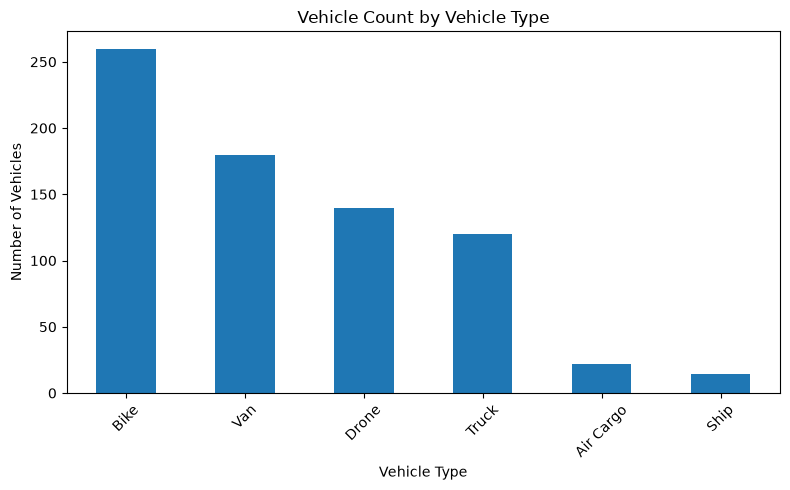

In [105]:


vehicle_type_counts = fleet_vehicles['vehicle_type'].value_counts()

plt.figure(figsize=(8, 5))
vehicle_type_counts.plot(kind='bar')

plt.title('Vehicle Count by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2. Fleet Status

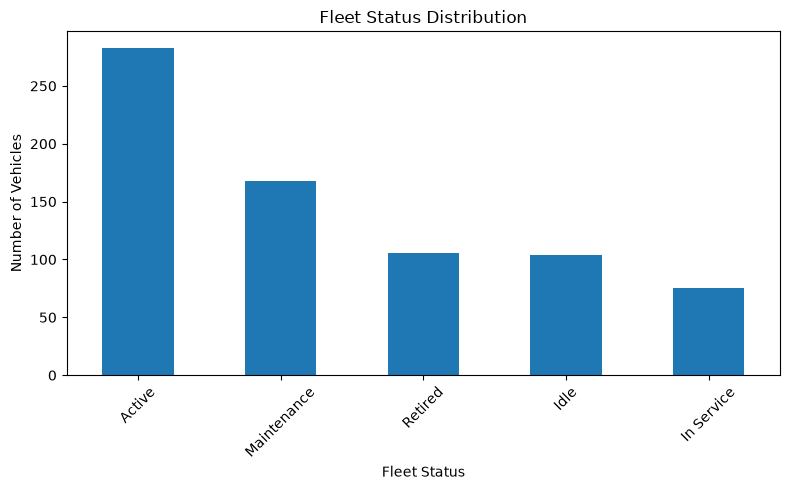

In [106]:
fleet_status_counts = fleet_vehicles['fleet_status'].value_counts()

plt.figure(figsize=(8, 5))
fleet_status_counts.plot(kind='bar')

plt.title('Fleet Status Distribution')
plt.xlabel('Fleet Status')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

3. Ownership Distribution

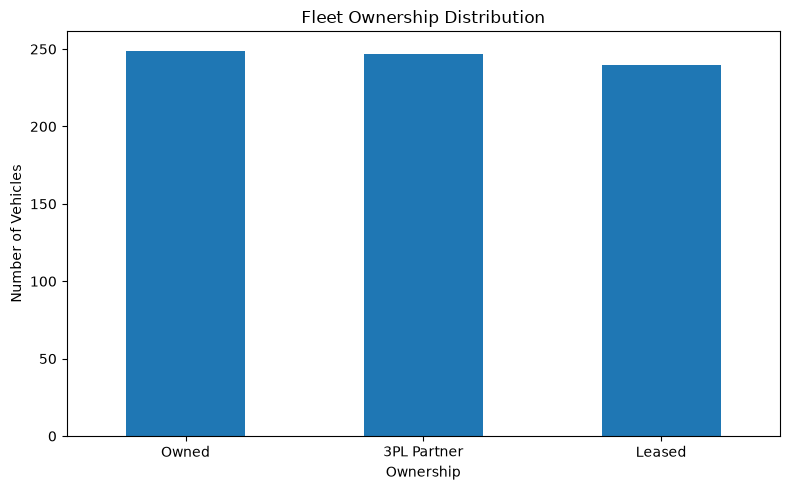

In [107]:
ownership_counts = fleet_vehicles['ownership'].value_counts()

plt.figure(figsize=(8, 5))
ownership_counts.plot(kind='bar')

plt.title('Fleet Ownership Distribution')
plt.xlabel('Ownership')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

4. Capacity by Vehicle Type

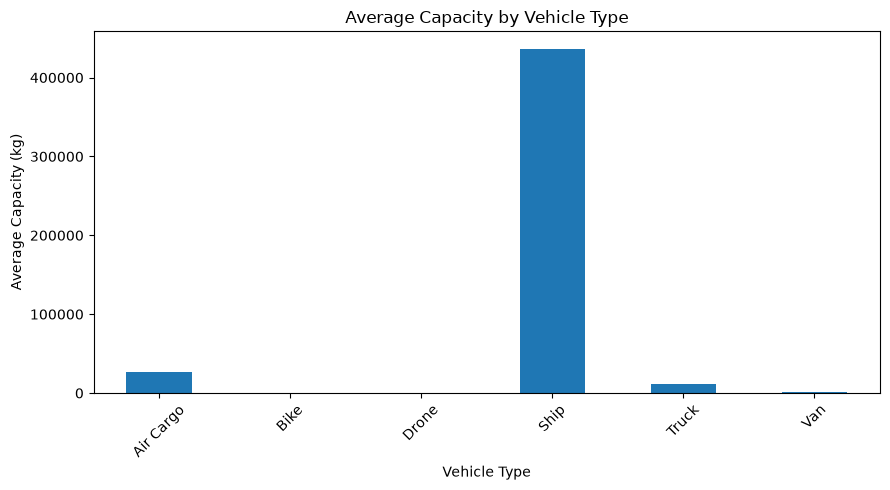

In [108]:
capacity_by_type = fleet_vehicles.groupby('vehicle_type')['capacity_kg'].mean()

plt.figure(figsize=(9, 5))
capacity_by_type.plot(kind='bar')

plt.title('Average Capacity by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Capacity (kg)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

5. Maximum Range by Vehicle Type

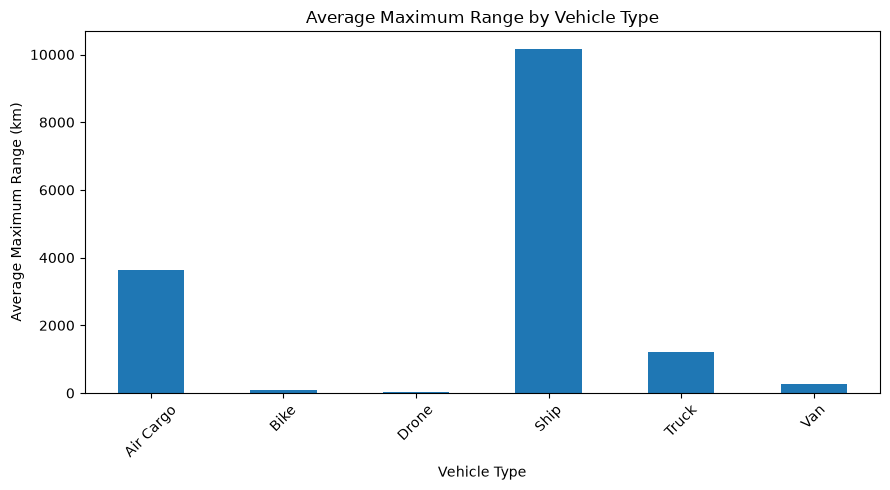

In [109]:
range_by_type = fleet_vehicles.groupby('vehicle_type')['max_range_km'].mean()

plt.figure(figsize=(9, 5))
range_by_type.plot(kind='bar')

plt.title('Average Maximum Range by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Maximum Range (km)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

6. Average Speed by Vehicle Type

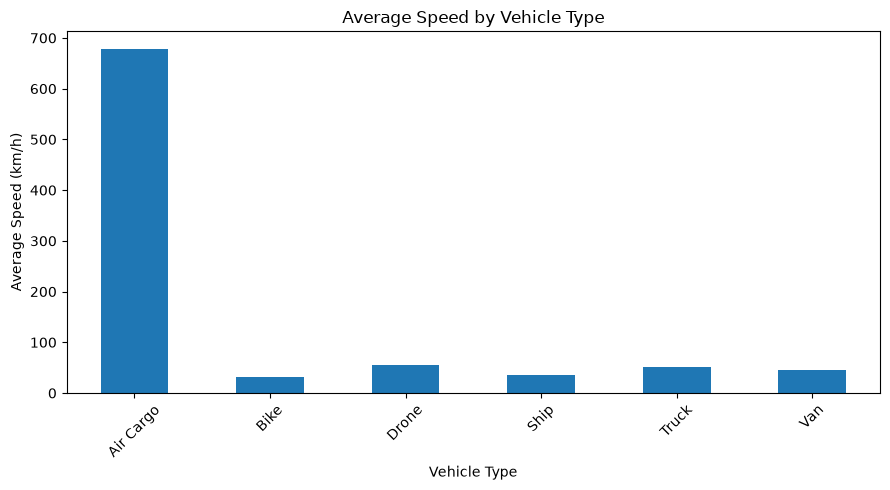

In [110]:
speed_by_type = fleet_vehicles.groupby('vehicle_type')['avg_speed_kmph'].mean()

plt.figure(figsize=(9, 5))
speed_by_type.plot(kind='bar')

plt.title('Average Speed by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Speed (km/h)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

7. Average Odometer by Vehicle Type

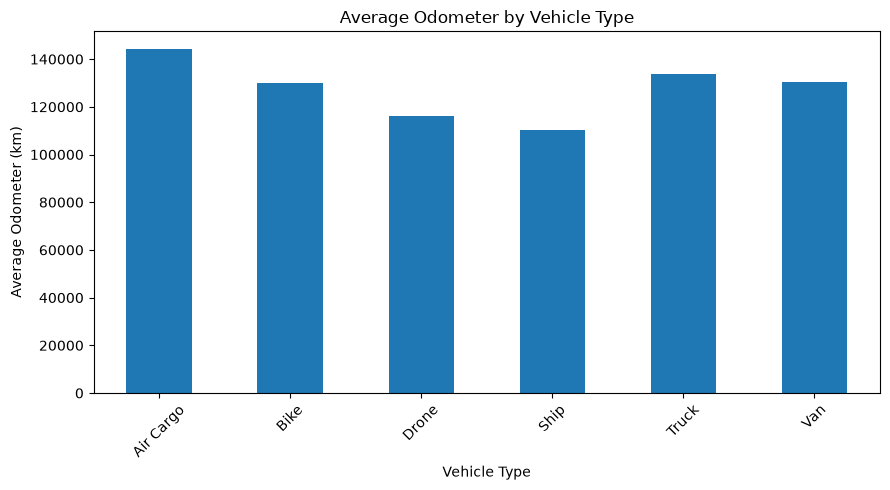

In [111]:
odometer_by_type = fleet_vehicles.groupby('vehicle_type')['odometer_km'].mean()

plt.figure(figsize=(9, 5))
odometer_by_type.plot(kind='bar')

plt.title('Average Odometer by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Odometer (km)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

8. Battery Capacity for Drones

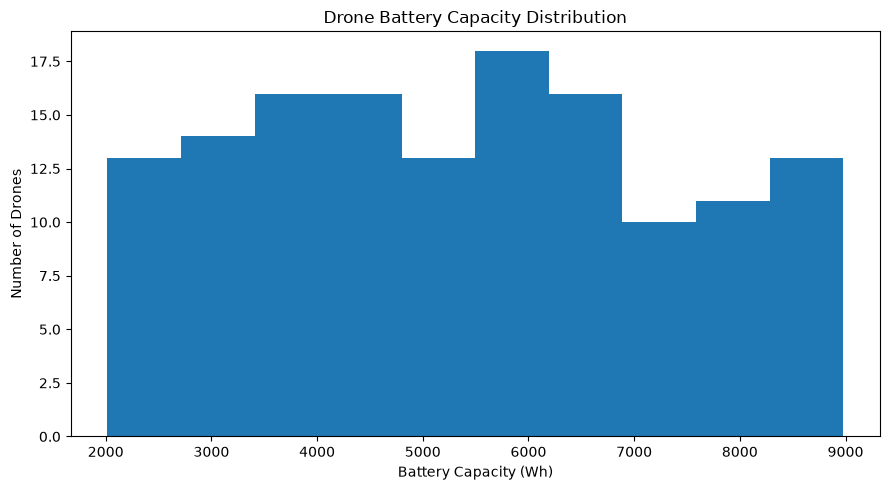

In [112]:
plt.figure(figsize=(9, 5))

fleet_vehicles.loc[
    fleet_vehicles['vehicle_type'] == 'Drone',
    'battery_capacity_wh'
].plot(kind='hist', bins=10)

plt.title('Drone Battery Capacity Distribution')
plt.xlabel('Battery Capacity (Wh)')
plt.ylabel('Number of Drones')
plt.tight_layout()
plt.show()

# 6. customer_reviews.jsonl

In [113]:
customer_reviews = pd.read_csv(
    '../cleaned_data/customer_reviews_cleaned.csv'
)

print(customer_reviews.shape)
print(customer_reviews.info())

(12000, 12)
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   review_id                  12000 non-null  str    
 1   order_id                   11754 non-null  str    
 2   product_id                 12000 non-null  str    
 3   customer_id                12000 non-null  str    
 4   rating                     12000 non-null  int64  
 5   review_title               7275 non-null   str    
 6   review_text                11536 non-null  str    
 7   review_date                12000 non-null  str    
 8   verified_purchase          12000 non-null  bool   
 9   helpful_votes              8053 non-null   float64
 10  delivery_mode_experienced  9999 non-null   str    
 11  sentiment_label            7783 non-null   str    
dtypes: bool(1), float64(1), int64(1), str(9)
memory usage: 2.6 MB
None


Missing values + duplicates

In [114]:
print(customer_reviews.isna().sum())

print("Duplicate rows:", customer_reviews.duplicated().sum())

print("Duplicate review IDs:",
      customer_reviews['review_id'].duplicated().sum())

review_id                       0
order_id                      246
product_id                      0
customer_id                     0
rating                          0
review_title                 4725
review_text                   464
review_date                     0
verified_purchase               0
helpful_votes                3947
delivery_mode_experienced    2001
sentiment_label              4217
dtype: int64
Duplicate rows: 0
Duplicate review IDs: 0


In [115]:
rating_counts = (
    pd.to_numeric(customer_reviews['rating'], errors='coerce')
    .value_counts()
    .sort_index()
)

print(rating_counts)

rating
1    1430
2    1396
3    2639
4    2180
5    4355
Name: count, dtype: int64


# Visualization

Rating distribution

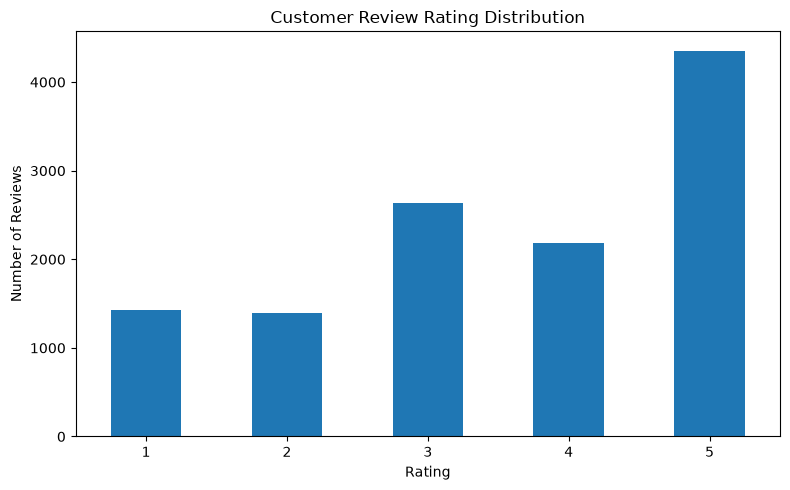

In [116]:
plt.figure(figsize=(8, 5))

rating_counts.plot(kind='bar')

plt.title('Customer Review Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Verified vs. Unverified Purchases

In [117]:
verified_rating = (
    customer_reviews.assign(
        rating_num=pd.to_numeric(customer_reviews['rating'], errors='coerce')
    )
    .groupby('verified_purchase')['rating_num']
    .mean()
)

print(verified_rating)

verified_purchase
False    3.532492
True     3.572772
Name: rating_num, dtype: float64


In [118]:
print(customer_reviews['verified_purchase'].value_counts(dropna=False))
print(customer_reviews['verified_purchase'].dtype)

verified_purchase
True     6060
False    5940
Name: count, dtype: int64
bool


1. Average Rating by Verified Purchase

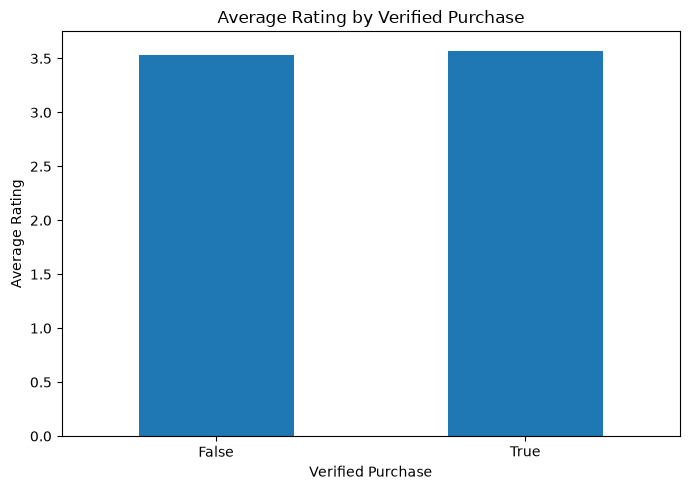

In [119]:
plt.figure(figsize=(7, 5))

verified_rating.plot(kind='bar')

plt.title('Average Rating by Verified Purchase')
plt.xlabel('Verified Purchase')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

3. Average Rating by Delivery Mode

In [120]:
delivery_rating = (
    customer_reviews.assign(
        rating_num=pd.to_numeric(customer_reviews['rating'], errors='coerce')
    )
    .groupby('delivery_mode_experienced')['rating_num']
    .mean()
)

print(delivery_rating)

delivery_mode_experienced
Bike     3.543699
Drone    3.563126
Truck    3.563857
Van      3.541302
Name: rating_num, dtype: float64


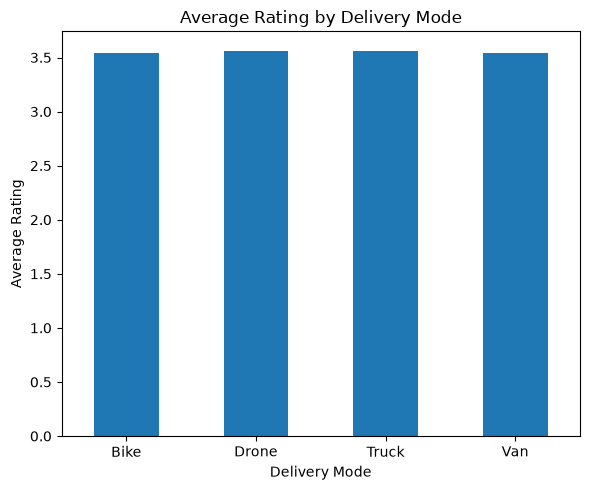

In [121]:
plt.figure(figsize=(6, 5))

delivery_rating.plot(kind='bar')

plt.title('Average Rating by Delivery Mode')
plt.xlabel('Delivery Mode')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

4. Helpful Votes by Rating

In [122]:
helpful_by_rating = (
    customer_reviews.assign(
        rating_num=pd.to_numeric(customer_reviews['rating'], errors='coerce')
    )
    .groupby('rating_num')['helpful_votes']
    .mean()
)

print(helpful_by_rating)

rating_num
1    43.991718
2    44.838405
3    45.302587
4    45.660014
5    44.877024
Name: helpful_votes, dtype: float64


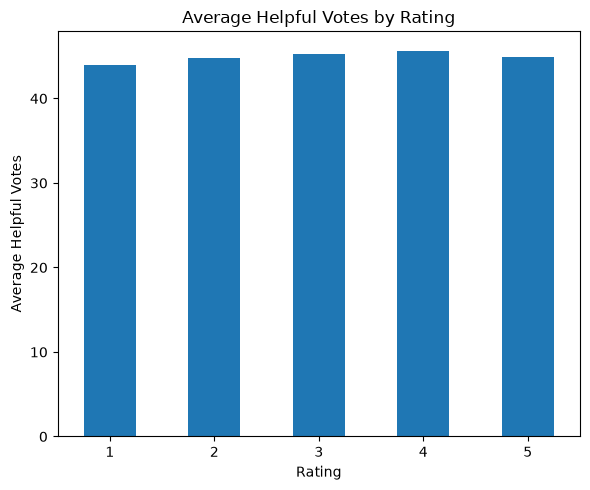

In [123]:
plt.figure(figsize=(6, 5))

helpful_by_rating.plot(kind='bar')

plt.title('Average Helpful Votes by Rating')
plt.xlabel('Rating')
plt.ylabel('Average Helpful Votes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

5. Number of Reviews by Delivery Mode

In [124]:
review_count_by_mode = (
    customer_reviews['delivery_mode_experienced']
    .value_counts()
)

print(review_count_by_mode)

delivery_mode_experienced
Drone    3992
Van      2058
Truck    1981
Bike     1968
Name: count, dtype: int64


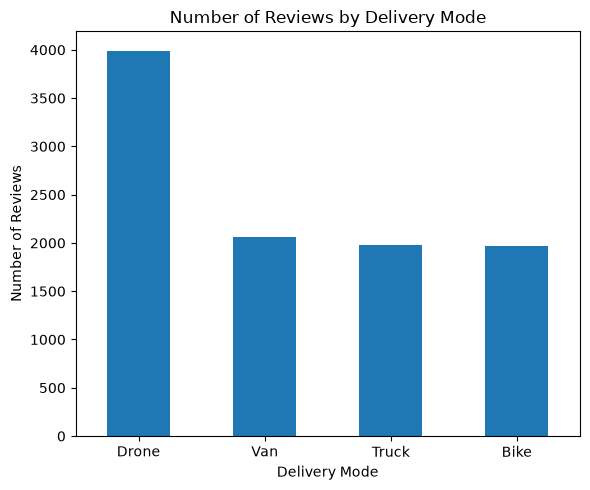

In [125]:
plt.figure(figsize=(6, 5))

review_count_by_mode.plot(kind='bar')

plt.title('Number of Reviews by Delivery Mode')
plt.xlabel('Delivery Mode')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

6. Sentiment Distribution

In [126]:
sentiment_counts = (
    customer_reviews['sentiment_label']
    .value_counts()
)

print(sentiment_counts)

sentiment_label
pos    4240
neg    1839
neu    1704
Name: count, dtype: int64


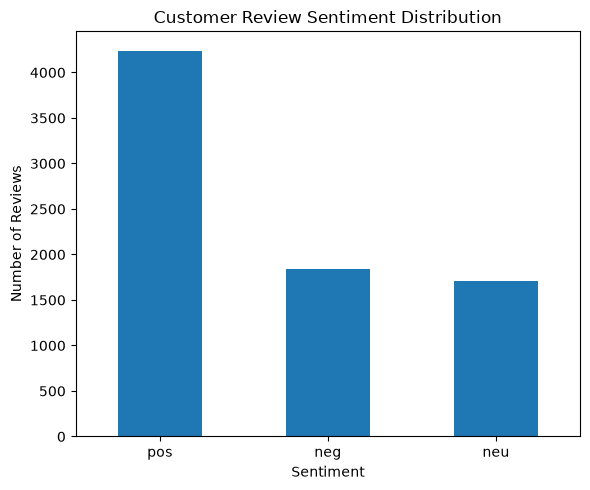

In [127]:
plt.figure(figsize=(6, 5))

sentiment_counts.plot(kind='bar')

plt.title('Customer Review Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

7. Average Rating by Sentiment

In [128]:
rating_by_sentiment = (
    customer_reviews.assign(
        rating_num=pd.to_numeric(customer_reviews['rating'], errors='coerce')
    )
    .groupby('sentiment_label')['rating_num']
    .mean()
)

print(rating_by_sentiment)

sentiment_label
neg    1.488853
neu    3.000000
pos    4.668396
Name: rating_num, dtype: float64


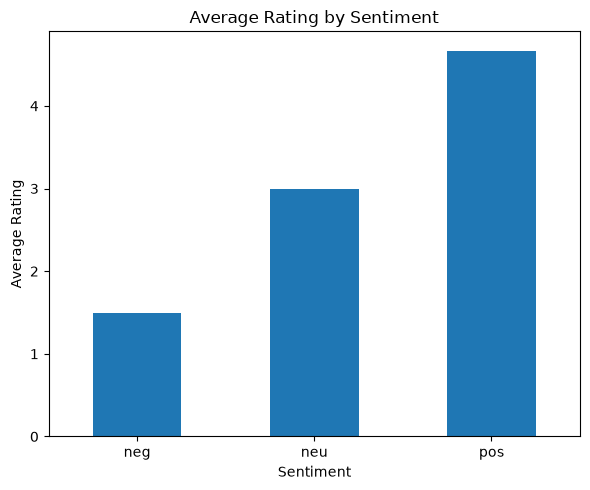

In [129]:
plt.figure(figsize=(6, 5))

rating_by_sentiment.plot(kind='bar')

plt.title('Average Rating by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 7. gps_routes.csv

In [130]:
gps_routes = pd.read_csv('../cleaned_data/gps_routes_cleaned.csv')

print(gps_routes.shape)
print(gps_routes.info())
print(gps_routes.isnull().sum())
print("Duplicate rows:", gps_routes.duplicated().sum())

(4000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   route_id              4000 non-null   str    
 1   vehicle_id            4000 non-null   str    
 2   vehicle_type          4000 non-null   str    
 3   route_date            4000 non-null   str    
 4   order_ids             4000 non-null   str    
 5   planned_distance_km   4000 non-null   float64
 6   actual_distance_km    3745 non-null   float64
 7   planned_duration_min  4000 non-null   float64
 8   actual_duration_min   4000 non-null   float64
 9   stops_planned         4000 non-null   int64  
 10  stops_completed       4000 non-null   int64  
 11  waypoints             4000 non-null   str    
 12  fuel_or_energy_used   4000 non-null   str    
 13  driver_id             3030 non-null   str    
dtypes: float64(4), int64(2), str(8)
memory usage: 3.9 MB
None
route_id      

check the important categorical/date fields

In [131]:
print("Vehicle Type:")
print(gps_routes['vehicle_type'].value_counts())

print("\nFuel / Energy:")
print(gps_routes['fuel_or_energy_used'].value_counts())

print("\nRoute Date:")
print(
    gps_routes['route_date'].min(),
    "to",
    gps_routes['route_date'].max()
)

Vehicle Type:
vehicle_type
Bike     1052
Van      1003
Truck     975
Drone     970
Name: count, dtype: int64

Fuel / Energy:
fuel_or_energy_used
1909.0 Wh    5
1725.0 Wh    4
2080.0 Wh    4
697.0 Wh     4
855.0 Wh     4
            ..
987.0 Wh     1
1621.0 Wh    1
53.57 L      1
42.28 L      1
15.81 L      1
Name: count, Length: 3366, dtype: int64

Route Date:
2024-01-01 00:00:00+00:00 to 2025-12-06 00:00:00+00:00


check the important numeric columns

In [132]:
gps_routes[
    [
        'planned_distance_km',
        'actual_distance_km',
        'planned_duration_min',
        'actual_duration_min',
        'stops_planned',
        'stops_completed'
    ]
].describe()

,planned_distance_km,actual_distance_km,planned_duration_min,actual_duration_min,stops_planned,stops_completed
count,4000.000000,3745.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,214.131703,231.244406,363.397400,402.383500,5.006500,4.824500
std,121.406948,131.941926,196.007981,228.597721,2.600028,2.648292
min,3.010000,3.010000,15.100000,15.000000,1.000000,0.000000
25%,108.985000,119.080000,197.050000,204.250000,3.000000,3.000000
50%,215.065000,229.730000,365.350000,401.300000,5.000000,5.000000
75%,321.052500,342.860000,528.150000,603.950000,7.000000,7.000000
max,419.980000,459.930000,700.000000,799.700000,9.000000,9.000000


# Visualization

Planned vs Actual Distance

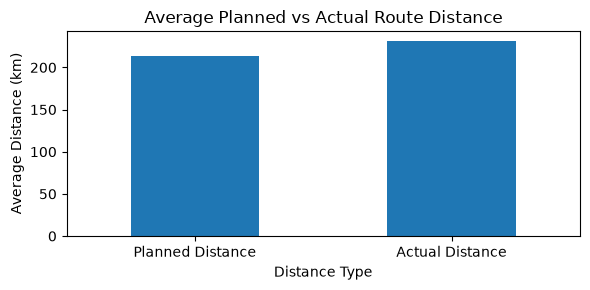

In [133]:
distance_comparison = pd.Series({
    'Planned Distance': gps_routes['planned_distance_km'].mean(),
    'Actual Distance': gps_routes['actual_distance_km'].mean()
})

plt.figure(figsize=(6, 3))

distance_comparison.plot(kind='bar')

plt.title('Average Planned vs Actual Route Distance')
plt.xlabel('Distance Type')
plt.ylabel('Average Distance (km)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Planned vs Actual Duration

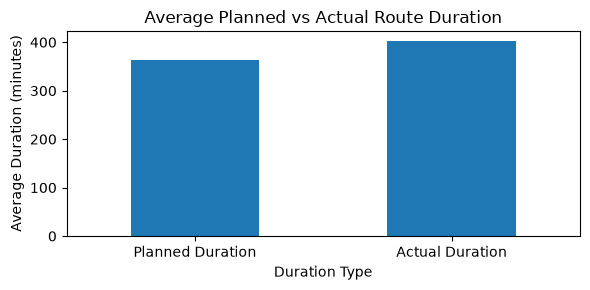

In [134]:
duration_comparison = pd.Series({
    'Planned Duration': gps_routes['planned_duration_min'].mean(),
    'Actual Duration': gps_routes['actual_duration_min'].mean()
})

plt.figure(figsize=(6, 3))

duration_comparison.plot(kind='bar')

plt.title('Average Planned vs Actual Route Duration')
plt.xlabel('Duration Type')
plt.ylabel('Average Duration (minutes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Route Distance by Vehicle Type

In [135]:
distance_by_type = (
    gps_routes.groupby('vehicle_type')['actual_distance_km']
    .mean()
)

print(distance_by_type)

vehicle_type
Bike     231.364626
Drone    229.596977
Truck    233.570429
Van      230.464695
Name: actual_distance_km, dtype: float64


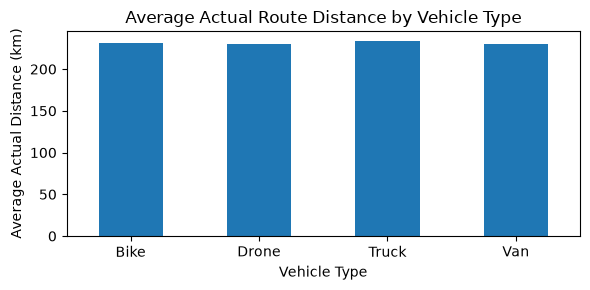

In [136]:
plt.figure(figsize=(6, 3))

distance_by_type.plot(kind='bar')

plt.title('Average Actual Route Distance by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Actual Distance (km)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Stop Completion Performance

In [137]:
stop_performance = pd.Series({
    'Stops Planned': gps_routes['stops_planned'].mean(),
    'Stops Completed': gps_routes['stops_completed'].mean()
})

print(stop_performance)

Stops Planned      5.0065
Stops Completed    4.8245
dtype: float64


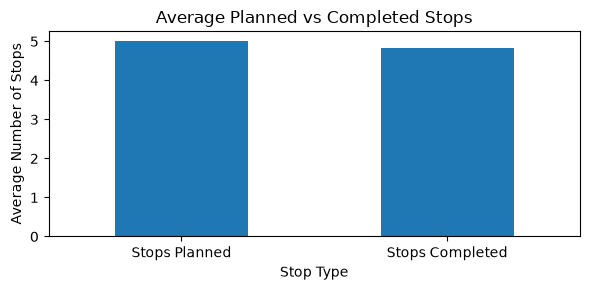

In [138]:
plt.figure(figsize=(6, 3))

stop_performance.plot(kind='bar')

plt.title('Average Planned vs Completed Stops')
plt.xlabel('Stop Type')
plt.ylabel('Average Number of Stops')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 8. maintenance_history.csv

In [139]:
maintenance_history = pd.read_csv('../cleaned_data/maintenance_history_cleaned.csv')

print(maintenance_history.shape)
print(maintenance_history.info())
print(maintenance_history.isnull().sum())
print("Duplicate rows:", maintenance_history.duplicated().sum())

(2014, 10)
<class 'pandas.DataFrame'>
RangeIndex: 2014 entries, 0 to 2013
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   work_order_id     2014 non-null   str    
 1   vehicle_id        2014 non-null   str    
 2   service_date      2014 non-null   str    
 3   service_type      2014 non-null   str    
 4   parts_replaced    1440 non-null   str    
 5   labour_hours      1928 non-null   float64
 6   cost_inr          2014 non-null   float64
 7   downtime_hours    2014 non-null   float64
 8   failure_reported  1602 non-null   object 
 9   technician_id     2014 non-null   str    
dtypes: float64(3), object(1), str(6)
memory usage: 303.4+ KB
None
work_order_id         0
vehicle_id            0
service_date          0
service_type          0
parts_replaced      574
labour_hours         86
cost_inr              0
downtime_hours        0
failure_reported    412
technician_id         0
dtype: int64
Duplicate

Check the important categorical fields

In [140]:
print("Service Type:")
print(maintenance_history['service_type'].value_counts())

print("\nFailure Reported:")
print(maintenance_history['failure_reported'].value_counts())

Service Type:
service_type
Brake Pad Replacement    231
Routine Inspection       223
Motor Overhaul           207
Landing Gear Fix         203
Propeller Replacement    201
Engine Service           199
Frame Repair             197
Tyre Change              187
Battery Pack Swap        184
Firmware Update          182
Name: count, dtype: int64

Failure Reported:
failure_reported
False    803
True     799
Name: count, dtype: int64


Numeric EDA

In [141]:
maintenance_history[
    [
        'labour_hours',
        'cost_inr',
        'downtime_hours'
    ]
].describe()

,labour_hours,cost_inr,downtime_hours
count,1928.000000,2014.000000,2014.000000
mean,7.128164,24262.754722,47.798610
std,3.860346,13594.222019,27.425214
min,0.500000,607.240000,1.000000
25%,3.800000,12748.242500,24.200000
50%,6.950000,24291.225000,47.700000
75%,10.500000,36147.815000,71.100000
max,14.000000,47997.360000,96.000000


# Visualization

Average Maintenance Cost by Service Type

In [142]:
cost_by_service = (
    maintenance_history.groupby('service_type')['cost_inr']
    .mean()
    .sort_values(ascending=False)
)

print(cost_by_service)

service_type
Landing Gear Fix         26244.936650
Motor Overhaul           25179.888841
Routine Inspection       24735.295291
Frame Repair             24661.960812
Propeller Replacement    24310.915025
Firmware Update          24028.020220
Tyre Change              23811.505134
Engine Service           23591.087236
Brake Pad Replacement    23146.830303
Battery Pack Swap        22809.578967
Name: cost_inr, dtype: float64


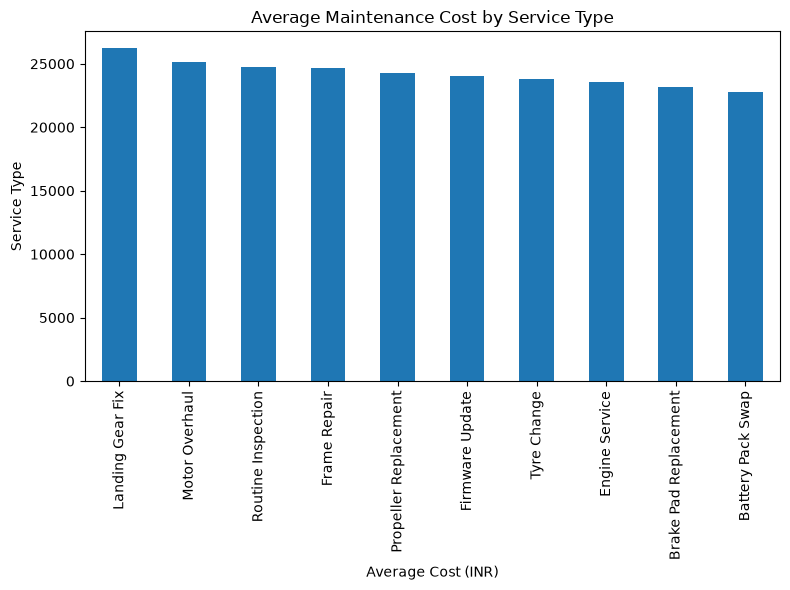

In [143]:
plt.figure(figsize=(8, 6))

cost_by_service.plot(kind='bar')

plt.title('Average Maintenance Cost by Service Type')
plt.xlabel('Average Cost (INR)')
plt.ylabel('Service Type')
plt.tight_layout()
plt.show()

Average Downtime by Service Type

In [144]:
downtime_by_service = (
    maintenance_history.groupby('service_type')['downtime_hours']
    .mean()
    .sort_values(ascending=False)
)

print(downtime_by_service)

service_type
Landing Gear Fix         49.452217
Motor Overhaul           49.089372
Tyre Change              48.644920
Frame Repair             48.310660
Propeller Replacement    48.019403
Brake Pad Replacement    47.493074
Routine Inspection       47.306278
Engine Service           46.686432
Battery Pack Swap        46.641304
Firmware Update          46.195604
Name: downtime_hours, dtype: float64


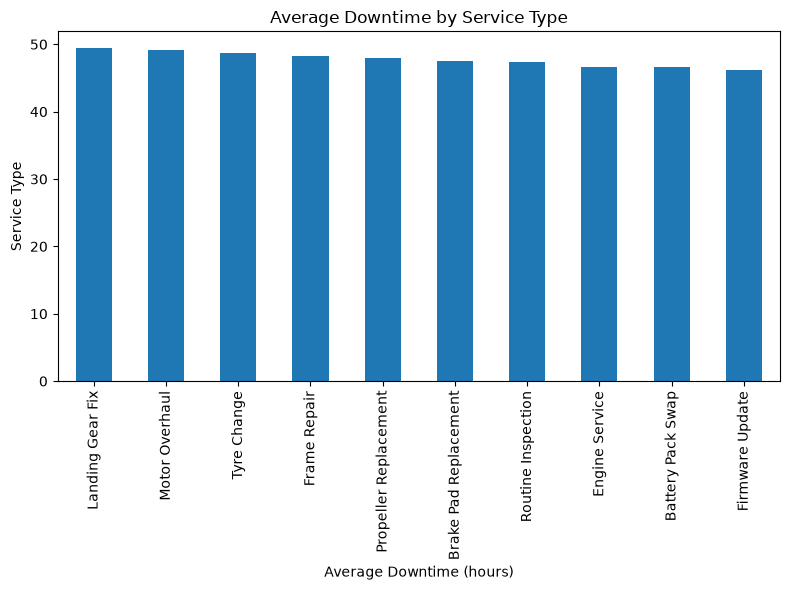

In [145]:
plt.figure(figsize=(8, 6))

downtime_by_service.plot(kind='bar')

plt.title('Average Downtime by Service Type')
plt.xlabel('Average Downtime (hours)')
plt.ylabel('Service Type')
plt.tight_layout()
plt.show()

Maintenance Cost vs Downtime

In [146]:
maintenance_summary = (
    maintenance_history
    .groupby('service_type')
    .agg(
        average_cost=('cost_inr', 'mean'),
        average_downtime=('downtime_hours', 'mean')
    )
    .reset_index()
)

print(maintenance_summary)

            service_type  average_cost  average_downtime
0      Battery Pack Swap  22809.578967         46.641304
1  Brake Pad Replacement  23146.830303         47.493074
2         Engine Service  23591.087236         46.686432
3        Firmware Update  24028.020220         46.195604
4           Frame Repair  24661.960812         48.310660
5       Landing Gear Fix  26244.936650         49.452217
6         Motor Overhaul  25179.888841         49.089372
7  Propeller Replacement  24310.915025         48.019403
8     Routine Inspection  24735.295291         47.306278
9            Tyre Change  23811.505134         48.644920


Average Labour Hours by Service Type

In [147]:
labour_by_service = (
    maintenance_history.groupby('service_type')['labour_hours']
    .mean()
    .sort_values(ascending=False)
)

print(labour_by_service)

service_type
Tyre Change              7.580226
Frame Repair             7.398370
Motor Overhaul           7.272864
Engine Service           7.172917
Battery Pack Swap        7.114525
Firmware Update          7.054023
Routine Inspection       7.046047
Brake Pad Replacement    7.015766
Propeller Replacement    6.902591
Landing Gear Fix         6.788083
Name: labour_hours, dtype: float64


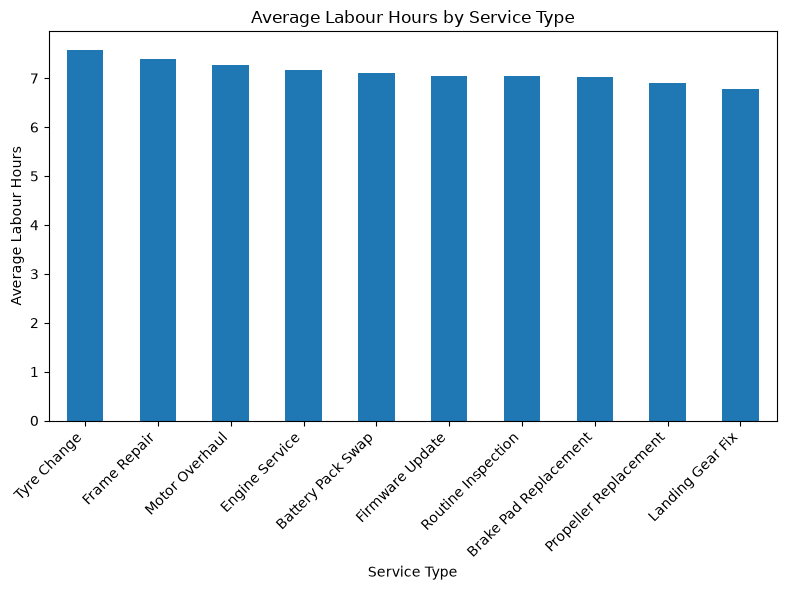

In [148]:
plt.figure(figsize=(8, 6))

labour_by_service.plot(kind='bar')

plt.title('Average Labour Hours by Service Type')
plt.xlabel('Service Type')
plt.ylabel('Average Labour Hours')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Failure Rate by Service Type

In [149]:
failure_by_service = (
    maintenance_history.dropna(subset=['failure_reported'])
    .groupby('service_type')['failure_reported']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(failure_by_service)

service_type
Firmware Update               55.0
Landing Gear Fix          54.43787
Tyre Change              53.642384
Routine Inspection       52.513966
Battery Pack Swap        50.331126
Motor Overhaul           50.299401
Engine Service           49.342105
Brake Pad Replacement    47.567568
Frame Repair             46.451613
Propeller Replacement    39.215686
Name: failure_reported, dtype: object


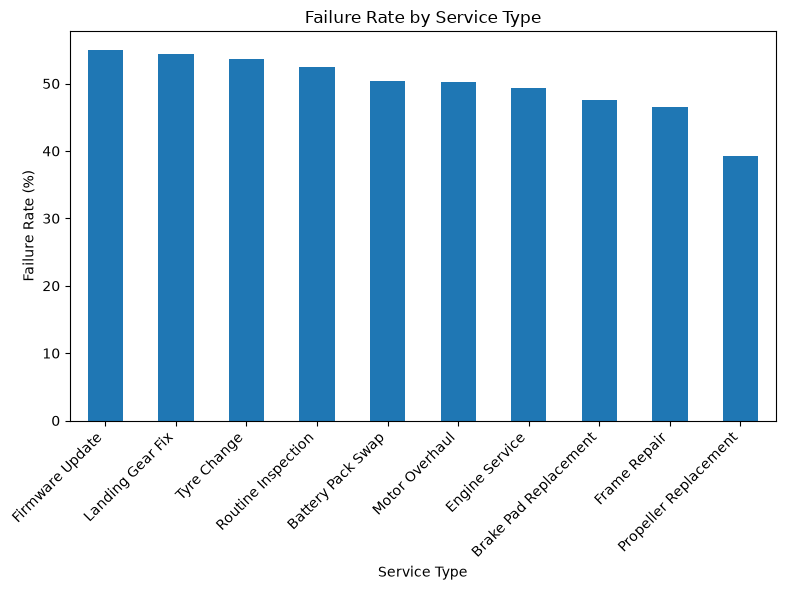

In [150]:
plt.figure(figsize=(8, 6))

failure_by_service.plot(kind='bar')

plt.title('Failure Rate by Service Type')
plt.xlabel('Service Type')
plt.ylabel('Failure Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 9. product_catalog.csv

In [151]:
product_catalog = pd.read_csv('../cleaned_data/product_catalog_cleaned.csv')

print(product_catalog.shape)
print(product_catalog.info())
print(product_catalog.isnull().sum())
print("Duplicate rows:", product_catalog.duplicated().sum())

(876, 18)
<class 'pandas.DataFrame'>
RangeIndex: 876 entries, 0 to 875
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  876 non-null    str    
 1   product_name                876 non-null    str    
 2   category                    876 non-null    str    
 3   sub_category                876 non-null    str    
 4   is_fragile                  876 non-null    bool   
 5   is_hazmat                   876 non-null    bool   
 6   requires_cold_chain         876 non-null    bool   
 7   stock_qty                   876 non-null    int64  
 8   avg_rating                  833 non-null    float64
 9   tags                        876 non-null    str    
 10  launch_date                 876 non-null    str    
 11  specs.weight_kg             812 non-null    float64
 12  specs.battery_included      558 non-null    object 
 13  price.currency              876 non-

Check the important categorical fields

In [152]:
print("Category:")
print(product_catalog['category'].value_counts())

print("\nSub-category:")
print(product_catalog['sub_category'].value_counts())

print("\nFragile:")
print(product_catalog['is_fragile'].value_counts())

print("\nHazmat:")
print(product_catalog['is_hazmat'].value_counts())

print("\nCold Chain:")
print(product_catalog['requires_cold_chain'].value_counts())

Category:
category
Apparel           119
Electronics       110
Furniture         107
Groceries         106
Industrial        106
Books              98
Pharma             94
Home Appliance     91
pharma             12
home appliance      6
apparel             6
groceries           6
electronics         5
furniture           5
industrial          3
books               2
Name: count, dtype: int64

Sub-category:
sub_category
Steel Coil        43
Textbook          42
Medical Kit       41
Cooking Oil       39
Vaccine Box       36
Motor Assembly    35
Saree             34
Jacket            34
Recliner          31
Generator Unit    31
Bookshelf         31
T-Shirt           30
Novel             29
Comic Set         29
Insulin Pack      29
Dry Fruits        28
Running Shoes     27
Air Purifier      27
Spice Pack        27
Smartphone        26
Vacuum Cleaner    26
Study Table       26
Headphones        25
Office Chair      24
Mixer Grinder     23
Smartwatch        22
Microwave         21
Laptop  

Check price, rating, and stock

In [153]:
product_catalog[
    [
        'stock_qty',
        'avg_rating',
        'price.amount'
    ]
].describe()

,stock_qty,avg_rating,price.amount
count,876.000000,833.000000,876.000000
mean,441.044521,3.770096,98212.987477
std,274.297568,0.734934,54800.684576
min,-20.000000,2.500000,495.710000
25%,195.000000,3.120000,49548.175000
50%,450.500000,3.780000,102218.100000
75%,684.500000,4.460000,145967.797500
max,900.000000,5.000000,188846.300000


# Visualization

Average Price by Category

In [154]:
price_by_category = (
    product_catalog.groupby('category')['price.amount']
    .mean()
    .sort_values(ascending=False)
)

print(price_by_category)

category
industrial        105602.420000
electronics       104654.568000
Books             104319.430918
Pharma            103055.917128
apparel           101693.411667
Furniture         101336.578972
Apparel           100109.297395
pharma             99566.150833
groceries          97572.255000
Industrial         97281.857170
Groceries          96080.198302
Electronics        92462.932000
Home Appliance     92294.793626
books              91300.800000
furniture          82658.098000
home appliance     79251.605000
Name: price.amount, dtype: float64


In [155]:
product_catalog['category'] = (
    product_catalog['category']
    .str.strip()
    .str.title()
)

print(product_catalog['category'].value_counts())

category
Apparel           125
Electronics       115
Groceries         112
Furniture         112
Industrial        109
Pharma            106
Books             100
Home Appliance     97
Name: count, dtype: int64


In [156]:
price_by_category = (
    product_catalog.groupby('category')['price.amount']
    .mean()
    .sort_values(ascending=False)
)

print(price_by_category)

category
Books             104059.058300
Pharma            102660.849245
Furniture         100502.718214
Apparel           100185.334880
Industrial         97510.863486
Groceries          96160.129911
Electronics        92993.003130
Home Appliance     91487.998454
Name: price.amount, dtype: float64


# Visualization

Average Product Price by Category

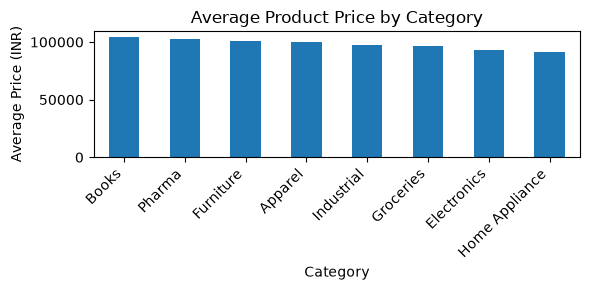

In [157]:
plt.figure(figsize=(6,3))

price_by_category.plot(kind='bar')

plt.title('Average Product Price by Category')
plt.xlabel('Category')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Average Rating by Category

In [158]:
rating_by_category = (
    product_catalog.groupby('category')['avg_rating']
    .mean()
    .sort_values(ascending=False)
)

print(rating_by_category)

category
Electronics       3.840091
Books             3.833895
Furniture         3.829038
Industrial        3.813939
Apparel           3.784034
Home Appliance    3.756087
Pharma            3.701456
Groceries         3.612162
Name: avg_rating, dtype: float64


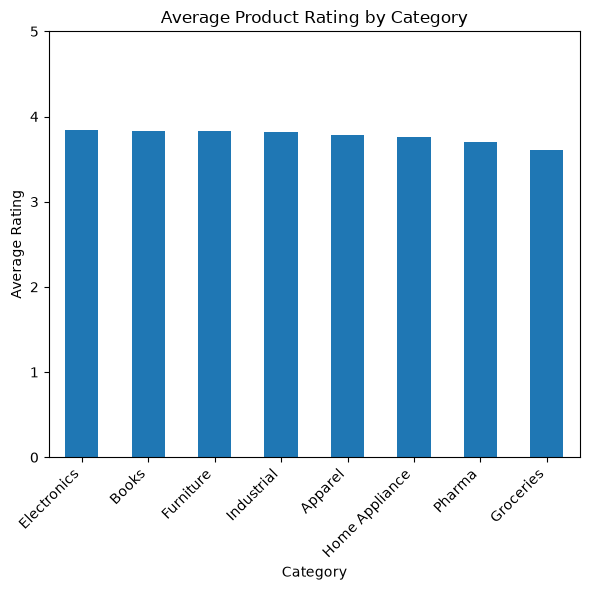

In [159]:
plt.figure(figsize=(6,6))

rating_by_category.plot(kind='bar')

plt.title('Average Product Rating by Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

Average Stock Quantity by Category

In [160]:
stock_by_category = (
    product_catalog.groupby('category')['stock_qty']
    .mean()
    .sort_values(ascending=False)
)

print(stock_by_category)

category
Home Appliance    470.268041
Industrial        458.155963
Groceries         448.035714
Furniture         447.580357
Books             431.910000
Apparel           431.752000
Electronics       422.773913
Pharma            421.811321
Name: stock_qty, dtype: float64


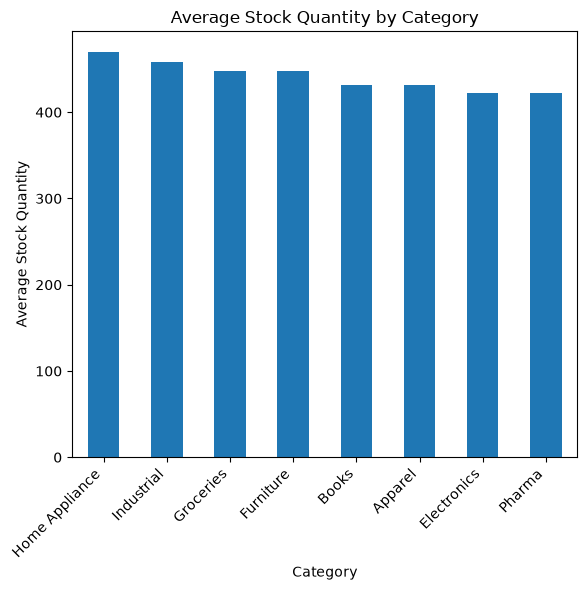

In [161]:
plt.figure(figsize=(6, 6))

stock_by_category.plot(kind='bar')

plt.title('Average Stock Quantity by Category')
plt.xlabel('Category')
plt.ylabel('Average Stock Quantity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Special-Handling Products

In [162]:
special_handling = pd.Series({
    'Fragile': product_catalog['is_fragile'].sum(),
    'Hazmat': product_catalog['is_hazmat'].sum(),
    'Cold Chain': product_catalog['requires_cold_chain'].sum()
})

print(special_handling)

Fragile       398
Hazmat        215
Cold Chain     58
dtype: int64


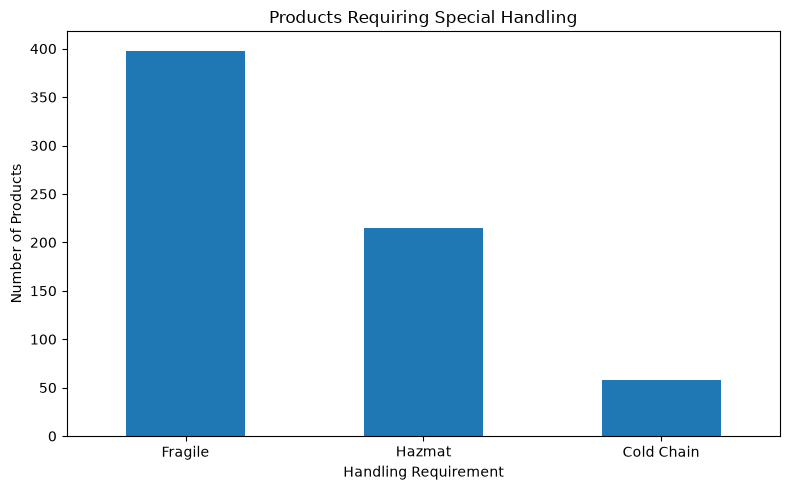

In [163]:
plt.figure(figsize=(8, 5))

special_handling.plot(kind='bar')

plt.title('Products Requiring Special Handling')
plt.xlabel('Handling Requirement')
plt.ylabel('Number of Products')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 10. traffic_data_cleaned.csv.csv

In [164]:
traffic_data = pd.read_csv('../cleaned_data/traffic_data_cleaned.csv')

print(traffic_data.shape)
print(traffic_data.info())
print(traffic_data.isnull().sum())
print("Duplicate rows:", traffic_data.duplicated().sum())

(19728, 8)
<class 'pandas.DataFrame'>
RangeIndex: 19728 entries, 0 to 19727
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   record_date        19728 non-null  str    
 1   hour_of_day        19728 non-null  int64  
 2   city               19728 non-null  str    
 3   corridor           19728 non-null  str    
 4   congestion_index   19728 non-null  float64
 5   avg_speed_kmph     19149 non-null  float64
 6   incident_reported  19728 non-null  bool   
 7   road_closure       18319 non-null  object 
dtypes: bool(1), float64(2), int64(1), object(1), str(3)
memory usage: 1.9+ MB
None
record_date             0
hour_of_day             0
city                    0
corridor                0
congestion_index        0
avg_speed_kmph        579
incident_reported       0
road_closure         1409
dtype: int64
Duplicate rows: 0


Check the important traffic dimensions

In [165]:
print("Cities:")
print(traffic_data['city'].value_counts())

print("\nCorridors:")
print(traffic_data['corridor'].value_counts())

print("\nIncidents:")
print(traffic_data['incident_reported'].value_counts())

print("\nRoad Closures:")
print(traffic_data['road_closure'].value_counts(dropna=False))

Cities:
city
Kochi            1056
Ahmedabad        1056
Coimbatore       1044
Bengaluru        1020
Hyderabad        1020
Delhi            1020
Gurugram         1014
Jaipur            984
Nagpur            984
Madurai           978
Kolkata           972
Pune              972
Mumbai            972
Chandigarh        960
Visakhapatnam     960
Mysuru            954
Chennai           954
Lucknow           948
Bhubaneswar       948
Guwahati          912
Name: count, dtype: int64

Corridors:
corridor
Central Market     2534
Industrial Belt    2525
IT Corridor        2521
Ring Road          2514
Airport Link       2424
NH-44 Stretch      2421
Old Town Bypass    2396
Port Access Rd     2393
Name: count, dtype: int64

Incidents:
incident_reported
False    14520
True      5208
Name: count, dtype: int64

Road Closures:
road_closure
False    17409
NaN       1409
True       910
Name: count, dtype: int64


# Visualization

In [166]:
congestion_by_city = (
    traffic_data.groupby('city')['congestion_index']
    .mean()
    .sort_values(ascending=False)
)

print(congestion_by_city)

city
Guwahati         12.521304
Visakhapatnam    11.505567
Nagpur           10.803987
Mysuru           10.708173
Delhi            10.616685
Bengaluru        10.502374
Kolkata          10.418547
Hyderabad        10.357672
Lucknow          10.233036
Chennai          10.218983
Bhubaneswar      10.170718
Coimbatore       10.089164
Madurai          10.003994
Chandigarh        9.958108
Ahmedabad         9.904299
Jaipur            9.844351
Gurugram          9.741808
Kochi             9.712219
Pune              9.672400
Mumbai            8.962967
Name: congestion_index, dtype: float64


Average Congestion by City

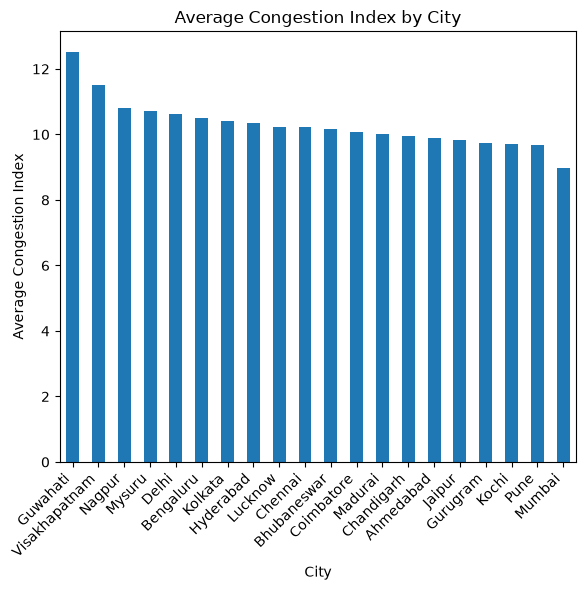

In [167]:
plt.figure(figsize=(6, 6))

congestion_by_city.plot(kind='bar')

plt.title('Average Congestion Index by City')
plt.xlabel('City')
plt.ylabel('Average Congestion Index')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Average Congestion by Hour

In [168]:
congestion_by_hour = (
    traffic_data.groupby('hour_of_day')['congestion_index']
    .mean()
    .sort_index()
)

print(congestion_by_hour)

hour_of_day
7     12.562766
10     7.659122
13     7.623643
17    12.846001
20    13.312573
23     7.707174
Name: congestion_index, dtype: float64


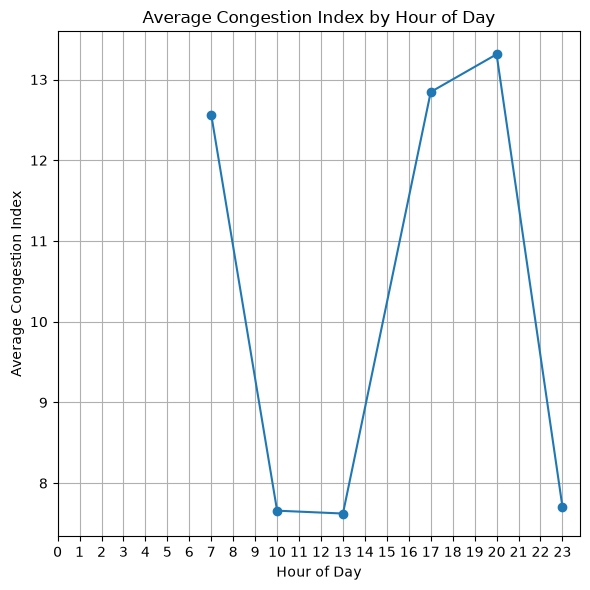

In [169]:
plt.figure(figsize=(6, 6))

congestion_by_hour.plot(kind='line', marker='o')

plt.title('Average Congestion Index by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Congestion Index')
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()

Average Speed by Hour

In [170]:
speed_by_hour = (
    traffic_data.groupby('hour_of_day')['avg_speed_kmph']
    .mean()
    .sort_index()
)

print(speed_by_hour)

hour_of_day
7     25.695222
10    39.488150
13    39.480281
17    25.973390
20    26.122247
23    39.457129
Name: avg_speed_kmph, dtype: float64


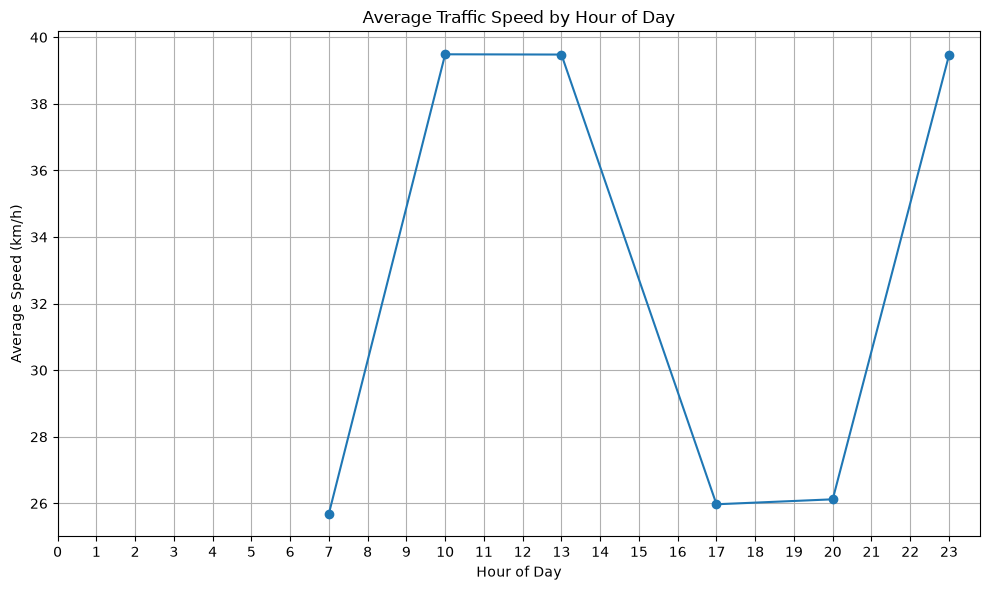

In [171]:
plt.figure(figsize=(10, 6))

speed_by_hour.plot(kind='line', marker='o')

plt.title('Average Traffic Speed by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Speed (km/h)')
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()

Average Congestion by Corridor

In [172]:
congestion_by_corridor = (
    traffic_data.groupby('corridor')['congestion_index']
    .mean()
    .sort_values(ascending=False)
)

print(congestion_by_corridor)

corridor
NH-44 Stretch      10.892335
Old Town Bypass    10.693486
Ring Road          10.574724
Port Access Rd     10.143654
Airport Link       10.123371
IT Corridor        10.102873
Industrial Belt    10.029968
Central Market      9.756144
Name: congestion_index, dtype: float64


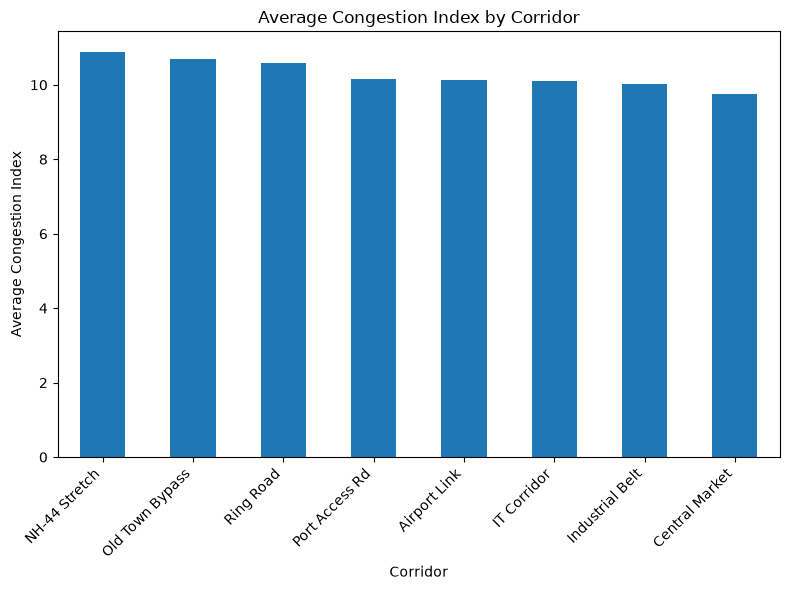

In [173]:
plt.figure(figsize=(8, 6))

congestion_by_corridor.plot(kind='bar')

plt.title('Average Congestion Index by Corridor')
plt.xlabel('Corridor')
plt.ylabel('Average Congestion Index')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 11. weather_data_cleaned.csv

In [174]:
weather_data = pd.read_csv('../cleaned_data/weather_data_cleaned.csv')

print(weather_data.shape)
print(weather_data.info())
print(weather_data.isnull().sum())
print("Duplicate rows:", weather_data.duplicated().sum())

(10749, 9)
<class 'pandas.DataFrame'>
RangeIndex: 10749 entries, 0 to 10748
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                10749 non-null  str    
 1   City Name           10749 non-null  str    
 2   humidity_%          10749 non-null  float64
 3   Precipitation (mm)  10749 non-null  float64
 4   wind_speed_kmph     10749 non-null  float64
 5   Visibility_KM       10749 non-null  float64
 6   condition           10749 non-null  str    
 7   storm_alert         10261 non-null  object 
 8   temp_celsius        7881 non-null   float64
dtypes: float64(5), object(1), str(3)
memory usage: 1.1+ MB
None
Date                     0
City Name                0
humidity_%               0
Precipitation (mm)       0
wind_speed_kmph          0
Visibility_KM            0
condition                0
storm_alert            488
temp_celsius          2868
dtype: int64
Duplicate rows: 0


Check the important weather categories

In [175]:
print("Weather Conditions:")
print(weather_data['condition'].value_counts())

print("\nStorm Alerts:")
print(weather_data['storm_alert'].value_counts(dropna=False))

print("\nCities:")
print(weather_data['City Name'].value_counts())

Weather Conditions:
condition
Clear           3781
Cloudy          2103
Rain            1956
Sunny           1001
Fog              717
Heavy Rain       634
Thunderstorm     557
Name: count, dtype: int64

Storm Alerts:
storm_alert
False    9365
True      896
NaN       488
Name: count, dtype: int64

Cities:
City Name
Bhubaneswar      545
Lucknow          544
Ahmedabad        543
Mumbai           539
Chandigarh       539
Nagpur           538
Visakhapatnam    538
Chennai          537
Bengaluru        537
Pune             537
Delhi            537
Gurugram         537
Kochi            537
Guwahati         537
Hyderabad        536
Kolkata          536
Jaipur           536
Madurai          534
Mysuru           534
Coimbatore       528
Name: count, dtype: int64


# Visualization

Weather Condition Distribution

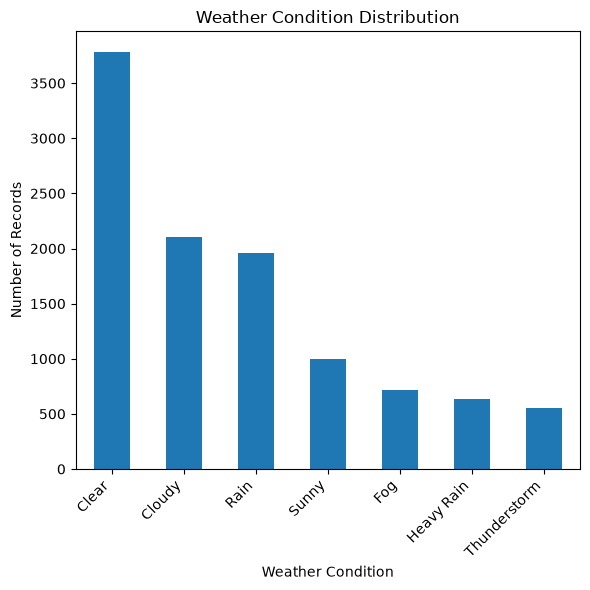

In [177]:
condition_counts = weather_data['condition'].value_counts()

plt.figure(figsize=(6, 6))
condition_counts.plot(kind='bar')

plt.title('Weather Condition Distribution')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Records')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Average Precipitation by City

In [178]:
precipitation_by_city = (
    weather_data.groupby('City Name')['Precipitation (mm)']
    .mean()
    .sort_values(ascending=False)
)

print(precipitation_by_city)

City Name
Jaipur           21.580970
Gurugram         20.161453
Bengaluru        20.150838
Bhubaneswar      19.941835
Nagpur           19.907249
Coimbatore       19.808144
Ahmedabad        19.566667
Mysuru           19.553371
Visakhapatnam    19.262268
Mumbai           19.221521
Pune             18.986778
Madurai          18.944944
Delhi            18.792924
Lucknow          18.725368
Hyderabad        18.305597
Chandigarh       17.994620
Guwahati         17.808380
Kolkata          17.603172
Kochi            16.619553
Chennai          16.564991
Name: Precipitation (mm), dtype: float64


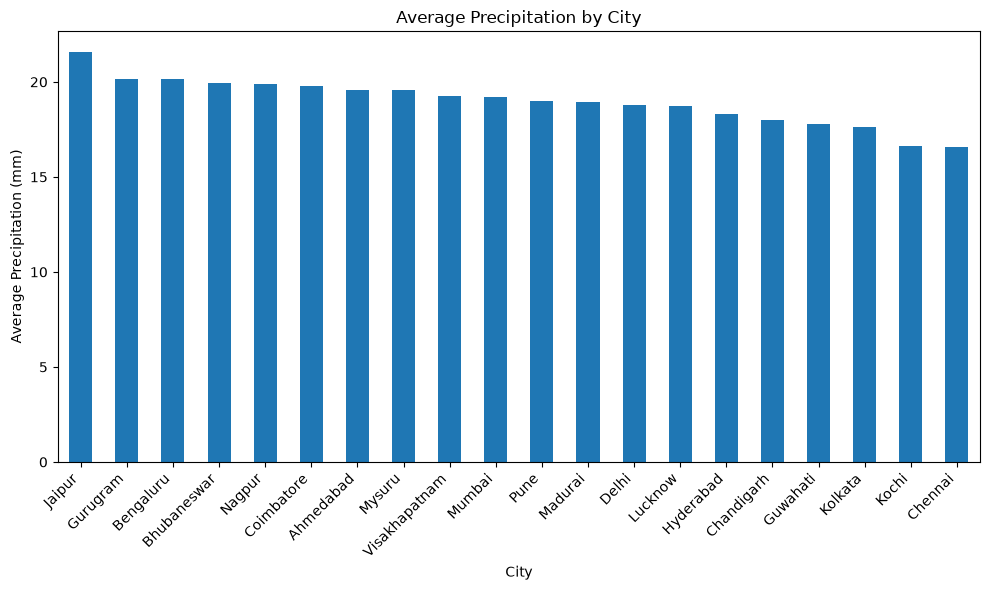

In [179]:
plt.figure(figsize=(10, 6))

precipitation_by_city.plot(kind='bar')

plt.title('Average Precipitation by City')
plt.xlabel('City')
plt.ylabel('Average Precipitation (mm)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Average Temperature by City

In [180]:
temperature_by_city = (
    weather_data.groupby('City Name')['temp_celsius']
    .mean()
    .sort_values(ascending=False)
)

print(temperature_by_city)

City Name
Jaipur           26.220495
Bengaluru        26.061287
Lucknow          25.911717
Bhubaneswar      25.752025
Chandigarh       25.750322
Ahmedabad        25.748222
Mysuru           25.733972
Mumbai           25.706876
Gurugram         25.682738
Visakhapatnam    25.661811
Delhi            25.659880
Kolkata          25.630077
Coimbatore       25.595960
Pune             25.542526
Guwahati         25.534861
Kochi            25.526285
Nagpur           25.514815
Madurai          25.493316
Hyderabad        25.381491
Chennai          25.242274
Name: temp_celsius, dtype: float64


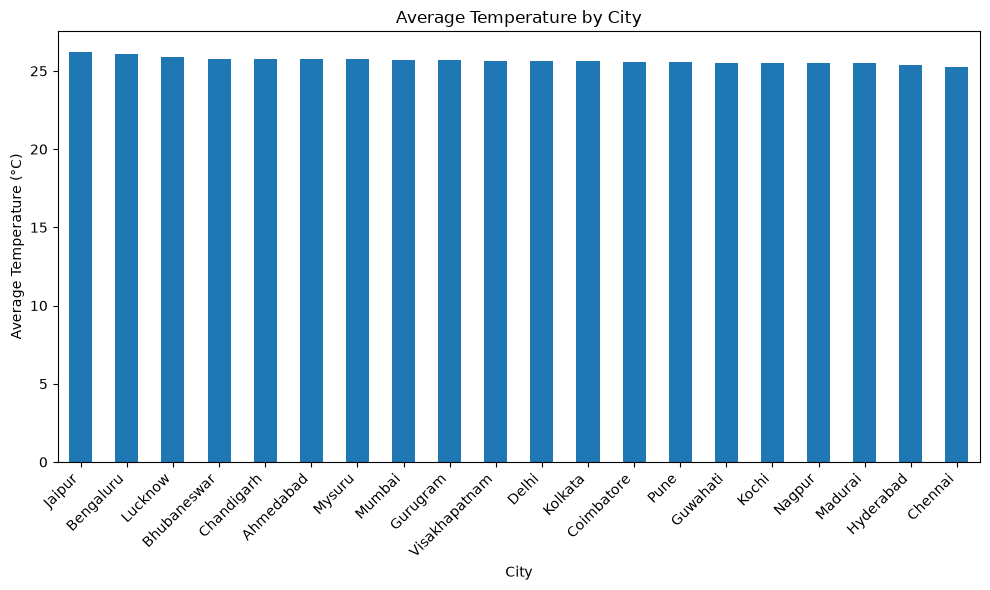

In [181]:
plt.figure(figsize=(10, 6))

temperature_by_city.plot(kind='bar')

plt.title('Average Temperature by City')
plt.xlabel('City')
plt.ylabel('Average Temperature (°C)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Storm Alerts by City

In [182]:
storm_by_city = (
    weather_data[weather_data['storm_alert'] == True]
    .groupby('City Name')
    .size()
    .sort_values(ascending=False)
)

print(storm_by_city)

City Name
Pune             60
Chandigarh       52
Nagpur           52
Gurugram         49
Hyderabad        49
Coimbatore       47
Bengaluru        47
Bhubaneswar      44
Lucknow          44
Jaipur           43
Kochi            43
Chennai          43
Ahmedabad        42
Mysuru           42
Visakhapatnam    42
Guwahati         41
Kolkata          41
Mumbai           39
Madurai          39
Delhi            37
dtype: int64


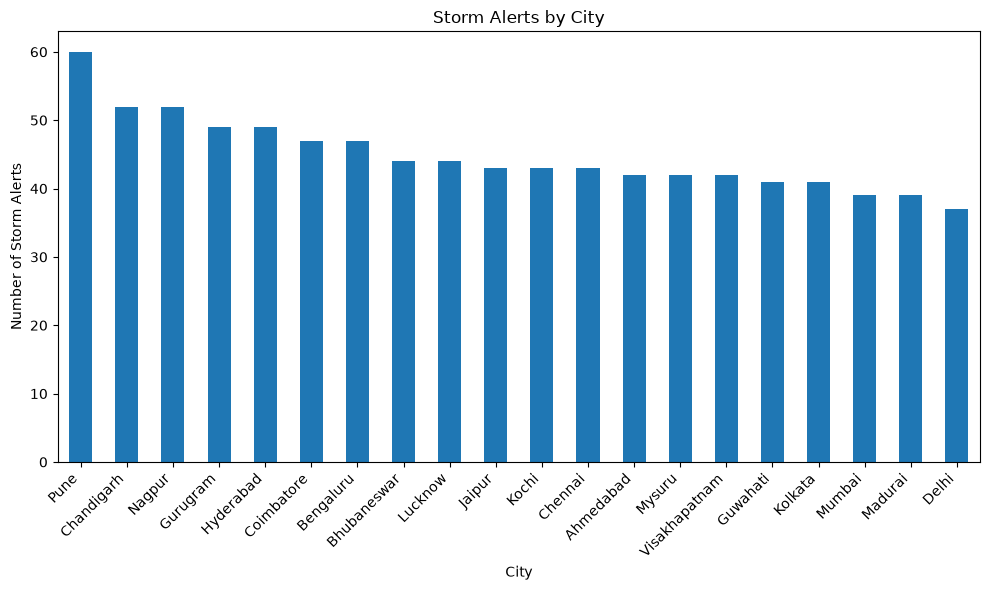

In [183]:
plt.figure(figsize=(10, 6))

storm_by_city.plot(kind='bar')

plt.title('Storm Alerts by City')
plt.xlabel('City')
plt.ylabel('Number of Storm Alerts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()